# Competitors Performance Analysis

Evaluate protein function prediction competitors against manually entered S2F metrics. Competitor outputs are normalized to the S2F-style tidy format (`protein_id`, `term_id`, `score`) and evaluated per organism using the same GOA/GO ontology metric code used in `performance_analysis.ipynb`.

S2F is not loaded from run outputs or configuration files in this notebook. Add S2F results only in the manual dictionary below.

## Imports and shared paths

This cell reads `s2f.conf` only for shared database locations such as filtered GOA and `go.obo`. It does not inspect S2F run outputs or deprecated weight-grid configs.

In [17]:
from pathlib import Path
import configparser
import os
import re
import sys
from collections import defaultdict

MPLCONFIGDIR = Path('/tmp') / 'matplotlib-s2f'
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')

# Backwards-compatibility for deprecated NumPy aliases used by legacy modules.
if not hasattr(np, 'float'):
    np.float = float  # type: ignore[attr-defined]
if not hasattr(np, 'int'):
    np.int = int  # type: ignore[attr-defined]
if not hasattr(np, 'bool'):
    np.bool = bool  # type: ignore[attr-defined]

CONFIG_CANDIDATES = [Path('s2f.conf'), Path('../s2f.conf')]
CONFIG_PATH = next((path for path in CONFIG_CANDIDATES if path.exists()), None)
if CONFIG_PATH is None:
    searched = ', '.join(str(path.resolve()) for path in CONFIG_CANDIDATES)
    raise FileNotFoundError(f'Configuration file not found. Searched: {searched}')

config = configparser.ConfigParser()
config.read(CONFIG_PATH)
PROJECT_ROOT = CONFIG_PATH.resolve().parent

COMPETITORS_DIR = PROJECT_ROOT / 'competitors'
if not COMPETITORS_DIR.exists():
    raise FileNotFoundError(f'Competitors directory not found: {COMPETITORS_DIR}')

FILTERED_GOA_PATH = Path(config.get('databases', 'filtered_goa', fallback='filtered_goa')).expanduser()
if not FILTERED_GOA_PATH.exists():
    raise FileNotFoundError(f'Filtered GOA file not found: {FILTERED_GOA_PATH}')

DEFAULT_OBO_PATH = PROJECT_ROOT / 'go.obo'
if not DEFAULT_OBO_PATH.exists():
    raise FileNotFoundError(f'GO ontology file not found: {DEFAULT_OBO_PATH}')

DEFAULT_EVIDENCE_CODES = [
    code.strip()
    for code in config.get('options', 'evidence_codes', fallback='EXP,IDA,IPI,IMP,IGI,IEP,TAS,IC').split(',')
    if code.strip()
]

repo_root = str(PROJECT_ROOT)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from Measures.measures import HX_py
from GOTool.GeneOntology import GeneOntology

PROJECT_ROOT, COMPETITORS_DIR, FILTERED_GOA_PATH

(PosixPath('/home/marcelo_baez/paccanaro-lab/S2F'),
 PosixPath('/home/marcelo_baez/paccanaro-lab/S2F/competitors'),
 PosixPath('/media/marcelo_baez/HD_Disc1/.S2F/data/UniprotKB/filtered_goa'))

## Organisms, models, and S2F prediction source

S2F is evaluated from prediction files, not from manually entered metric numbers. The only accepted S2F source for an organism is a strict `<organism>/prediction.df` folder under one of the configured backup roots. Variant folders such as `83333_w_equal` are intentionally ignored.

In [18]:
ORGANISMS_TO_EVALUATE = ['83333', '223283', '1111708']
MODELS_TO_EVALUATE = ['S2F', 'TALE', 'ATGO', 'PANDA2']  # TEMPROT is still a placeholder until files are added.
MODEL_ORDER = ['S2F', 'TALE', 'ATGO', 'PANDA2', 'TEMPROT']

# Use explicit competitor test-set inputs to define the fair protein universe for every model.
# TALE can be added here, but reading its full output only to infer proteins is slow.
COMPETITOR_TEST_SET_MODELS = ['ATGO', 'PANDA2']
EVALUATION_PROTEIN_SET_MODE = 'intersection'  # 'intersection' is the strict fair comparison; 'union' is less strict.

S2F_BACKUP_ROOTS = [
    Path(value).expanduser()
    for value in [
        os.environ.get('S2F_BACKUP_ROOT'),
        '/run/media/marcelo_baez/SSD_Disc1/backup',
        '/media/marcelo_baez/SSD_Disc1/backup',
    ]
    if value
]
S2F_CHUNK_SIZE = 1_000_000

METRIC_SPECS = {
    'AUC': ('AUC per-gene', 'AUC per-term'),
    'AUPR': ('AUPR per-gene', 'AUPR per-term'),
    'F_max': ('F_max per-gene', 'F_max per-term'),
    'smin': ('smin per-gene', 'smin per-term'),
}
METRIC_COLUMNS = [column for columns in METRIC_SPECS.values() for column in columns]


def s2f_prediction_candidates(organism):
    return [root / str(organism) / 'prediction.df' for root in S2F_BACKUP_ROOTS]


def s2f_prediction_path(organism):
    candidates = s2f_prediction_candidates(organism)
    for path in candidates:
        if path.exists():
            return path
    return candidates[0]


def s2f_similar_dirs(organism):
    names = []
    for root in S2F_BACKUP_ROOTS:
        if root.exists():
            names.extend(
                path.name for path in root.glob(f'{organism}*')
                if path.is_dir() and path.name != str(organism)
            )
    return sorted(set(names))


def validate_s2f_prediction_paths(organisms=ORGANISMS_TO_EVALUATE):
    rows = []
    if isinstance(organisms, str):
        organisms = [organisms]
    selected_organisms = [str(organism).strip() for organism in organisms if str(organism).strip()]
    for organism in selected_organisms:
        expected_path = s2f_prediction_path(organism)
        similar_dirs = s2f_similar_dirs(organism)
        rows.append({
            'organism': organism,
            'expected_prediction_path': str(expected_path),
            'exists': expected_path.exists(),
            'size_bytes': expected_path.stat().st_size if expected_path.exists() else np.nan,
            'ignored_similar_folders': ', '.join(similar_dirs),
        })
    return pd.DataFrame(rows)


S2F_PATH_STATUS = validate_s2f_prediction_paths()
if not S2F_PATH_STATUS['exists'].all():
    missing = S2F_PATH_STATUS.loc[~S2F_PATH_STATUS['exists'], 'expected_prediction_path'].tolist()
    print('Missing strict S2F prediction files. Variant folders are ignored by design:')
    for missing_path in missing:
        print(f'  - {missing_path}')

S2F_PATH_STATUS

,organism,expected_prediction_path,exists,size_bytes,ignored_similar_folders
0,83333,/media/marcelo_baez/SSD_Disc1/backup/83333/pre...,True,12948817824,"83333_w_equal, 83333_w_foldseek_heavy, 83333_w..."
1,223283,/media/marcelo_baez/SSD_Disc1/backup/223283/pr...,True,4217938972,
2,1111708,/media/marcelo_baez/SSD_Disc1/backup/1111708/p...,True,2783202025,


## GOA-derived organism protein sets and ground truth

Organism membership comes from GOA taxon filtering, not S2F config FASTA files. The same filtered GOA annotations are used to prepare the ground truth matrices.

In [19]:
_GOA_CACHE = {}
_GROUND_TRUTH_CACHE = {}


def _resolved_path(path) -> Path:
    return Path(path).expanduser().resolve()


def normalise_organisms(organisms):
    if isinstance(organisms, str):
        organisms = [organisms]
    return [str(organism).strip() for organism in organisms if str(organism).strip()]


def load_goa_annotations_for_taxon(taxon_id, goa_path=FILTERED_GOA_PATH, evidence_codes=DEFAULT_EVIDENCE_CODES, chunk_size=200_000):
    goa_path = _resolved_path(goa_path)
    cache_key = (goa_path, str(taxon_id), tuple(sorted(evidence_codes)) if evidence_codes else ())
    if cache_key in _GOA_CACHE:
        return _GOA_CACHE[cache_key].copy()

    column_names = [
        'DB', 'DB Object ID', 'DB Object Symbol', 'Qualifier', 'GO ID',
        'DB Reference', 'Evidence Code', 'With', 'Aspect', 'DB Object Name',
        'Synonym', 'DB Object Type', 'Taxon', 'Date', 'Assigned By',
        'Annotation Extension', 'Gene Product Form ID',
    ]
    dtype = {name: str for name in column_names}
    taxon_pattern = fr'(?:^|\|)taxon:{taxon_id}(?:$|\|)'
    not_pattern = r'(?:^|\|)NOT(?:$|\|)'
    annotations = []

    for chunk in pd.read_csv(
        goa_path,
        sep='	',
        comment='!',
        header=None,
        names=column_names,
        dtype=dtype,
        chunksize=chunk_size,
        low_memory=False,
    ):
        mask = chunk['Taxon'].fillna('').str.contains(taxon_pattern, regex=True)
        if not mask.any():
            continue

        subset = chunk.loc[mask]
        subset = subset[~subset['Qualifier'].fillna('').str.contains(not_pattern, regex=True)]
        if evidence_codes:
            subset = subset[subset['Evidence Code'].isin(evidence_codes)]
            if subset.empty:
                continue

        trimmed = subset[['DB Object ID', 'GO ID']].drop_duplicates()
        trimmed = trimmed.rename(columns={'DB Object ID': 'Protein'})
        trimmed['Score'] = 1.0
        annotations.append(trimmed)

    if annotations:
        result = pd.concat(annotations, ignore_index=True).drop_duplicates()
    else:
        result = pd.DataFrame(columns=['Protein', 'GO ID', 'Score'])

    _GOA_CACHE[cache_key] = result
    return result.copy()


def get_organism_protein_set(taxon_id):
    annotations = load_goa_annotations_for_taxon(taxon_id)
    proteins = set(annotations['Protein'].dropna().astype(str))
    if not proteins:
        raise ValueError(f'No GOA proteins found for taxon {taxon_id}.')
    return proteins


def prepare_ground_truth(taxon_id, obo_path=DEFAULT_OBO_PATH):
    taxon_id = str(taxon_id)
    cache_key = (taxon_id, _resolved_path(obo_path), FILTERED_GOA_PATH, tuple(sorted(DEFAULT_EVIDENCE_CODES)))
    if cache_key in _GROUND_TRUTH_CACHE:
        return _GROUND_TRUTH_CACHE[cache_key]

    annotations = load_goa_annotations_for_taxon(taxon_id)
    if annotations.empty:
        raise ValueError(f'No annotations retrieved from GOA for taxon {taxon_id}.')

    organism_name = f'gt_taxon_{taxon_id}'
    ontology = GeneOntology(str(obo_path), verbose=False)
    ontology.build_structure()

    valid_term = annotations['GO ID'].map(lambda term: term in ontology.terms or term in ontology.alias_map)
    annotations = annotations.loc[valid_term].copy()
    if annotations.empty:
        raise ValueError(f'No GOA annotations matched ontology terms for taxon {taxon_id}.')

    ontology.load_annotations(annotations, organism_name)
    ontology.up_propagate_annotations(organism_name)
    propagated_annotations = ontology.get_annotations(organism_name)

    prepared = {
        'annotations': propagated_annotations,
        'ontology': ontology,
        'organism_name': organism_name,
    }
    _GROUND_TRUTH_CACHE[cache_key] = prepared
    return prepared


ORGANISMS_TO_EVALUATE = normalise_organisms(ORGANISMS_TO_EVALUATE)
ORGANISM_PROTEIN_SETS = {
    organism: get_organism_protein_set(organism)
    for organism in ORGANISMS_TO_EVALUATE
}

protein_counts = pd.DataFrame(
    [{'organism': organism, 'goa_proteins': len(proteins)} for organism, proteins in ORGANISM_PROTEIN_SETS.items()]
)
protein_counts

,organism,goa_proteins
0,83333,3458
1,223283,4
2,1111708,120


## Shared prediction and evaluation helpers

Competitor parsers return the same tidy prediction columns that S2F uses: `protein_id`, `term_id`, and `score`. Evaluation consumes one model and one organism at a time to avoid keeping all large predictions in memory.

In [20]:
PREDICTION_COLUMNS = ['protein_id', 'term_id', 'score']


def empty_prediction_frame(model=None, organism=None):
    df = pd.DataFrame(columns=[*PREDICTION_COLUMNS, 'model', 'organism'])
    if model is not None:
        df['model'] = df['model'].astype('object')
    if organism is not None:
        df['organism'] = df['organism'].astype('object')
    return df.astype({'score': 'float32'}, errors='ignore')


def normalise_protein_set(protein_set):
    if protein_set is None:
        return None
    if isinstance(protein_set, (str, bytes)):
        protein_set = [protein_set]
    return {str(protein).strip() for protein in protein_set if str(protein).strip()}


def normalise_prediction_frame(df, model, organism):
    if df is None or df.empty:
        return empty_prediction_frame(model=model, organism=organism)

    result = df.copy()
    result = result.rename(columns={'Protein': 'protein_id', 'GO ID': 'term_id', 'Score': 'score'})
    missing = [column for column in PREDICTION_COLUMNS if column not in result.columns]
    if missing:
        raise ValueError(f'{model} predictions for {organism} are missing columns: {missing}')

    result = result[PREDICTION_COLUMNS].copy()
    result['protein_id'] = result['protein_id'].astype(str).str.strip()
    result['term_id'] = result['term_id'].astype(str).str.strip()
    result['score'] = pd.to_numeric(result['score'], errors='coerce')
    result = result.dropna(subset=['protein_id', 'term_id', 'score'])
    result = result[result['protein_id'].ne('') & result['term_id'].str.match(r'^GO:\d+$')]
    result['model'] = model
    result['organism'] = str(organism)

    if result.empty:
        return empty_prediction_frame(model=model, organism=organism)

    result = (
        result.groupby(['protein_id', 'term_id', 'model', 'organism'], as_index=False, sort=False)['score']
        .max()
    )
    result['score'] = result['score'].astype('float32')
    return result


def build_prediction_and_gold_matrices(predictions, annotations):
    if annotations.empty:
        raise ValueError('Ground-truth annotations are empty.')

    if predictions.empty:
        pred_proteins = set()
        pred_terms = set()
    else:
        pred_proteins = set(predictions['protein_id'])
        pred_terms = set(predictions['term_id'])

    proteins = sorted(pred_proteins | set(annotations['Protein']))
    terms = sorted(pred_terms | set(annotations['GO ID']))

    protein_to_idx = {protein: idx for idx, protein in enumerate(proteins)}
    term_to_idx = {term: idx for idx, term in enumerate(terms)}

    prediction_matrix = np.zeros((len(proteins), len(terms)), dtype=np.float32)
    if not predictions.empty:
        rows = predictions['protein_id'].map(protein_to_idx).to_numpy()
        cols = predictions['term_id'].map(term_to_idx).to_numpy()
        prediction_matrix[rows, cols] = predictions['score'].to_numpy(dtype=float)

    gold_matrix = np.zeros((len(proteins), len(terms)), dtype=np.float32)
    gt_rows = annotations['Protein'].map(protein_to_idx).to_numpy()
    gt_cols = annotations['GO ID'].map(term_to_idx).to_numpy()
    gold_matrix[gt_rows, gt_cols] = 1.0

    return prediction_matrix, gold_matrix, protein_to_idx, term_to_idx


def compute_information_content(term_to_idx, ontology, organism_name):
    ic = np.zeros(len(term_to_idx), dtype=np.float32)
    for term, idx in term_to_idx.items():
        try:
            ic[idx] = ontology.find_term(term).information_content(organism_name)
        except KeyError:
            ic[idx] = 0.0
    return ic


def filter_matrices(gold_matrix, prediction_matrix, ic_vector, min_annotations_per_protein=1, term_frequency_range=(1, None)):
    lower, upper = term_frequency_range
    upper = float('inf') if upper is None else upper

    sumrow = gold_matrix.sum(axis=1)
    sumcol = gold_matrix.sum(axis=0)

    row_mask = sumrow >= min_annotations_per_protein
    col_mask = (sumcol >= lower) & (sumcol <= upper)

    filtered_pred = prediction_matrix[row_mask][:, col_mask]
    filtered_gold = gold_matrix[row_mask][:, col_mask]
    filtered_ic = ic_vector[col_mask]

    return filtered_pred, filtered_gold, filtered_ic, row_mask, col_mask


def flatten_metrics(nested_metrics):
    flat = {}
    for block, metrics in nested_metrics.items():
        for key, value in metrics.items():
            if isinstance(value, (list, tuple, dict)):
                continue
            arr = np.asarray(value)
            if arr.ndim == 0:
                label = key if block != 'overall' else f'{block}::{key}'
                flat[label] = float(arr)
    return flat


def filter_annotations_to_proteins(annotations, protein_set):
    selected = normalise_protein_set(protein_set)
    if selected is None:
        return annotations.copy()
    return annotations[annotations['Protein'].astype(str).isin(selected)].copy()


def evaluate_prediction_table(
    model,
    organism,
    predictions,
    evaluation_protein_set=None,
    min_annotations_per_protein=1,
    term_frequency_range=(1, None),
):
    evaluation_proteins = normalise_protein_set(evaluation_protein_set)
    predictions = normalise_prediction_frame(predictions, model=model, organism=organism)

    ground_truth = prepare_ground_truth(organism)
    annotations = ground_truth['annotations']
    ontology = ground_truth['ontology']
    organism_name = ground_truth['organism_name']

    if evaluation_proteins is not None:
        predictions = predictions[predictions['protein_id'].isin(evaluation_proteins)].copy()
        annotations = filter_annotations_to_proteins(annotations, evaluation_proteins)
        if annotations.empty:
            raise ValueError(f'No GOA annotations overlap the evaluation protein set for organism {organism}.')

    # Existing S2F evaluation drops zero-frequency terms after matrix creation.
    # Filtering to ground-truth terms first gives the same result for the default lower bound of 1 and reduces memory use.
    valid_terms = set(annotations['GO ID'])
    predictions = predictions[predictions['term_id'].isin(valid_terms)].copy()

    prediction_matrix, gold_matrix, protein_to_idx, term_to_idx = build_prediction_and_gold_matrices(predictions, annotations)
    ic_vector = compute_information_content(term_to_idx, ontology, organism_name)
    filtered_pred, filtered_gold, filtered_ic, row_mask, col_mask = filter_matrices(
        gold_matrix,
        prediction_matrix,
        ic_vector,
        min_annotations_per_protein=min_annotations_per_protein,
        term_frequency_range=term_frequency_range,
    )

    if filtered_gold.size == 0 or filtered_gold.sum() == 0:
        raise ValueError(f'No annotations left after filtering for {model} on organism {organism}.')

    if np.unique(filtered_pred).size > 10000:
        filtered_pred = np.around(filtered_pred, decimals=4)

    measure = HX_py(filtered_pred, filtered_ic, organism_id=f'{model}_{organism}', verbose=False)
    results = {
        'overall': measure.compute_overall(filtered_gold),
        'per_gene': measure.compute_per_gene(filtered_gold),
        'per_term': measure.compute_per_term(filtered_gold),
    }
    context = {
        'organism': str(organism),
        'model': str(model),
        'label': str(model),
        'plot_label': str(model),
        'is_s2f': model.upper() == 'S2F',
        'evaluation_protein_set_size': len(evaluation_proteins) if evaluation_proteins is not None else np.nan,
        'predicted_proteins_in_evaluation_set': int(predictions['protein_id'].nunique()),
        'proteins_considered': int(row_mask.sum()),
        'terms_considered': int(col_mask.sum()),
        'total_annotations': int(filtered_gold.sum()),
        'matrix_shape': filtered_gold.shape,
    }
    return {**context, **flatten_metrics(results)}


## S2F parser

S2F predictions are loaded from strict organism-id folders on the backup disk. The loader filters each chunk to the GOA-derived organism proteins and propagated ground-truth GO terms before evaluation.

In [21]:
def load_s2f_predictions_for_organism(organism, protein_set, chunk_size=S2F_CHUNK_SIZE):
    organism = str(organism)
    path = s2f_prediction_path(organism)
    if not path.exists():
        similar = s2f_similar_dirs(organism)
        message = f'S2F prediction file not found: {path}. Only exact organism-id folders are accepted.'
        if similar:
            message += f' Ignored similar folders: {similar}'
        raise FileNotFoundError(message)

    ground_truth = prepare_ground_truth(organism)
    valid_terms = set(ground_truth['annotations']['GO ID'])

    frames = []
    total_rows = 0
    kept_rows = 0
    for chunk in pd.read_csv(
        path,
        sep='	',
        header=None,
        names=PREDICTION_COLUMNS,
        usecols=[0, 1, 2],
        dtype={'protein_id': str, 'term_id': str, 'score': np.float32},
        na_filter=False,
        chunksize=chunk_size,
        low_memory=False,
        memory_map=True,
    ):
        total_rows += len(chunk)
        mask = chunk['protein_id'].isin(protein_set) & chunk['term_id'].isin(valid_terms)
        if mask.any():
            subset = chunk.loc[mask, PREDICTION_COLUMNS].copy()
            kept_rows += len(subset)
            frames.append(subset)

    if frames:
        df = pd.concat(frames, ignore_index=True)
    else:
        df = pd.DataFrame(columns=PREDICTION_COLUMNS)

    result = normalise_prediction_frame(df, model='S2F', organism=organism)
    print(
        f'S2F {organism}: {len(result):,} unique predictions from {kept_rows:,} kept rows '
        f'out of {total_rows:,} raw rows.'
    )
    return result

## TALE parser

TALE stores one large flat text file per ontology under `competitors/TALE/{bp,mf,cc}/output.txt`. The loader streams those files and keeps only proteins belonging to the requested organism's GOA protein set.

In [22]:
TALE_ONTOLOGY_FILES = {
    'bp': COMPETITORS_DIR / 'TALE' / 'bp' / 'output.txt',
    'mf': COMPETITORS_DIR / 'TALE' / 'mf' / 'output.txt',
    'cc': COMPETITORS_DIR / 'TALE' / 'cc' / 'output.txt',
}
TALE_PATTERN = re.compile(
    r"^(?P<protein>\S+)\s+\('(?P<term>GO:\d+)',.*\)\s+(?P<score>[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?)\s*$"
)


def load_tale_predictions_for_organism(organism, protein_set):
    rows = []
    parsed = defaultdict(int)
    malformed = defaultdict(int)
    organism = str(organism)

    for ontology, path in TALE_ONTOLOGY_FILES.items():
        if not path.exists():
            print(f'TALE {ontology}: missing {path}')
            continue

        with path.open('r', encoding='utf-8', errors='replace') as handle:
            for line in handle:
                match = TALE_PATTERN.match(line.rstrip())
                if match is None:
                    malformed[ontology] += 1
                    continue

                protein = match.group('protein')
                if protein not in protein_set:
                    continue

                rows.append((protein, match.group('term'), match.group('score')))
                parsed[ontology] += 1

    df = pd.DataFrame(rows, columns=PREDICTION_COLUMNS)
    result = normalise_prediction_frame(df, model='TALE', organism=organism)
    print(
        f'TALE {organism}: {len(result):,} unique predictions '
        f'from raw counts {dict(parsed)}; malformed lines {dict(malformed)}.'
    )
    return result

## ATGO parser

ATGO stores one result directory per protein and ontology. The loader reads only the proteins assigned to the requested organism. It prefers the sorted `_new` files and falls back to the base files when needed.

In [23]:
ATGO_ONTOLOGY_DIRS = {
    'BP': COMPETITORS_DIR / 'ATGO' / 'BP' / 'result',
    'MF': COMPETITORS_DIR / 'ATGO' / 'MF' / 'result',
    'CC': COMPETITORS_DIR / 'ATGO' / 'CC' / 'result',
}


def _atgo_prediction_file(protein, ontology):
    result_dir = ATGO_ONTOLOGY_DIRS[ontology] / protein
    preferred = result_dir / f'final_combine_{ontology}_new'
    fallback = result_dir / f'final_combine_{ontology}'
    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    return None


def load_atgo_predictions_for_organism(organism, protein_set):
    rows = []
    read_counts = defaultdict(int)
    missing_counts = defaultdict(int)
    malformed = defaultdict(int)
    organism = str(organism)

    for ontology, result_root in ATGO_ONTOLOGY_DIRS.items():
        if not result_root.exists():
            print(f'ATGO {ontology}: missing {result_root}')
            continue

        for protein in sorted(protein_set):
            path = _atgo_prediction_file(protein, ontology)
            if path is None:
                missing_counts[ontology] += 1
                continue

            with path.open('r', encoding='utf-8', errors='replace') as handle:
                for line in handle:
                    parts = line.strip().split()
                    if len(parts) < 3 or not parts[0].startswith('GO:'):
                        malformed[ontology] += 1
                        continue
                    rows.append((protein, parts[0], parts[-1]))
                    read_counts[ontology] += 1

    df = pd.DataFrame(rows, columns=PREDICTION_COLUMNS)
    result = normalise_prediction_frame(df, model='ATGO', organism=organism)
    print(
        f'ATGO {organism}: {len(result):,} unique predictions '
        f'from raw counts {dict(read_counts)}; missing proteins {dict(missing_counts)}; malformed lines {dict(malformed)}.'
    )
    return result

## PANDA2 parser

PANDA2 stores one consolidated prediction file per organism under `competitors/PANDA2/by_dataset/<organism>/<organism>.2/panda2_prediction.txt`. The file has a short CAFA-style header, tab-separated `protein`, `GO term`, and `score` rows, and a final `END` line.

In [24]:
PANDA2_BY_DATASET_DIR = COMPETITORS_DIR / 'PANDA2' / 'by_dataset'
PANDA2_HEADER_TOKENS = {'AUTHOR', 'MODEL', 'KEYWORDS', 'END'}


def _panda2_prediction_path(organism):
    organism = str(organism)
    expected = PANDA2_BY_DATASET_DIR / organism / f'{organism}.2' / 'panda2_prediction.txt'
    if expected.exists():
        return expected

    organism_dir = PANDA2_BY_DATASET_DIR / organism
    if not organism_dir.exists():
        return None

    candidates = sorted(organism_dir.glob('*/panda2_prediction.txt'))
    return candidates[0] if candidates else None


def load_panda2_predictions_for_organism(organism, protein_set):
    path = _panda2_prediction_path(organism)
    if path is None:
        print(f'PANDA2 {organism}: no panda2_prediction.txt found under {PANDA2_BY_DATASET_DIR / str(organism)}.')
        return empty_prediction_frame(model='PANDA2', organism=organism)

    rows = []
    parsed = 0
    skipped_other_proteins = 0
    malformed = 0

    with path.open('r', encoding='utf-8', errors='replace') as handle:
        for line in handle:
            parts = line.strip().split()
            if not parts:
                continue
            if parts[0] in PANDA2_HEADER_TOKENS:
                continue
            if len(parts) != 3 or not parts[1].startswith('GO:'):
                malformed += 1
                continue

            protein, term, score = parts
            if protein not in protein_set:
                skipped_other_proteins += 1
                continue

            rows.append((protein, term, score))
            parsed += 1

    df = pd.DataFrame(rows, columns=PREDICTION_COLUMNS)
    result = normalise_prediction_frame(df, model='PANDA2', organism=organism)
    print(
        f'PANDA2 {organism}: {len(result):,} unique predictions from {parsed:,} parsed rows; '
        f'skipped {skipped_other_proteins:,} rows outside GOA taxon proteins; malformed lines {malformed:,}.'
    )
    return result


## TEMPROT parser placeholder

`competitors/TEMPROT` is currently empty. Replace this cell with a parser when TEMPROT output files are added.

In [25]:
def load_temprot_predictions_for_organism(organism, protein_set):
    temprot_dir = COMPETITORS_DIR / 'TEMPROT'
    files = list(temprot_dir.rglob('*')) if temprot_dir.exists() else []
    files = [path for path in files if path.is_file()]
    if files:
        raise NotImplementedError('TEMPROT files exist, but a parser has not been implemented yet.')
    print(f'TEMPROT {organism}: no files found under {temprot_dir}.')
    return empty_prediction_frame(model='TEMPROT', organism=organism)

## Competitor-derived evaluation protein sets


In [26]:
def _read_id_list(path):
    path = Path(path)
    if not path.exists():
        return set()
    with path.open('r', encoding='utf-8', errors='replace') as handle:
        return {line.strip().split()[0] for line in handle if line.strip()}


def read_atgo_test_proteins():
    proteins = set()
    for ontology, result_root in ATGO_ONTOLOGY_DIRS.items():
        test_list = result_root.parent / 'test_gene_list'
        ontology_proteins = _read_id_list(test_list)
        if not ontology_proteins and result_root.exists():
            ontology_proteins = {path.name for path in result_root.iterdir() if path.is_dir()}
        proteins.update(ontology_proteins)
    return proteins


def read_panda2_test_proteins(organism):
    organism = str(organism)
    input_dir = PANDA2_BY_DATASET_DIR / organism / organism
    if input_dir.exists():
        proteins = {path.stem for path in input_dir.glob('*.fasta') if path.is_file()}
        if proteins:
            return proteins

    path = _panda2_prediction_path(organism)
    if path is None:
        return set()

    proteins = set()
    with path.open('r', encoding='utf-8', errors='replace') as handle:
        for line in handle:
            parts = line.strip().split()
            if len(parts) == 3 and parts[0] not in PANDA2_HEADER_TOKENS and parts[1].startswith('GO:'):
                proteins.add(parts[0])
    return proteins


def read_tale_test_proteins():
    proteins = set()
    for path in TALE_ONTOLOGY_FILES.values():
        if not path.exists():
            continue
        with path.open('r', encoding='utf-8', errors='replace') as handle:
            for line in handle:
                match = TALE_PATTERN.match(line.rstrip())
                if match is not None:
                    proteins.add(match.group('protein'))
    return proteins


def read_competitor_test_proteins(model, organism):
    model = str(model).upper()
    if model == 'ATGO':
        return read_atgo_test_proteins()
    if model == 'PANDA2':
        return read_panda2_test_proteins(organism)
    if model == 'TALE':
        return read_tale_test_proteins()
    return set()


def build_evaluation_protein_set(organism, goa_protein_set, models=COMPETITOR_TEST_SET_MODELS, mode=EVALUATION_PROTEIN_SET_MODE):
    organism = str(organism)
    goa_proteins = normalise_protein_set(goa_protein_set)
    rows = []
    model_sets = []

    for model in models:
        raw_proteins = normalise_protein_set(read_competitor_test_proteins(model, organism))
        goa_overlap = raw_proteins & goa_proteins
        if goa_overlap:
            model_sets.append(goa_overlap)
        rows.append({
            'organism': organism,
            'source_model': model,
            'raw_test_proteins': len(raw_proteins),
            'goa_overlap_proteins': len(goa_overlap),
            'goa_proteins': len(goa_proteins),
            'protein_set_mode': mode,
        })

    if not model_sets:
        raise ValueError(f'No competitor test proteins overlap GOA proteins for organism {organism}.')

    if mode == 'intersection':
        selected = set.intersection(*model_sets)
    elif mode == 'union':
        selected = set.union(*model_sets)
    else:
        raise ValueError("EVALUATION_PROTEIN_SET_MODE must be 'intersection' or 'union'.")

    if not selected:
        raise ValueError(f'The {mode} competitor test protein set is empty for organism {organism}.')

    rows.append({
        'organism': organism,
        'source_model': 'SHARED_EVALUATION_SET',
        'raw_test_proteins': np.nan,
        'goa_overlap_proteins': len(selected),
        'goa_proteins': len(goa_proteins),
        'protein_set_mode': mode,
    })
    return selected, rows


EVALUATION_PROTEIN_SETS = {}
competitor_test_rows = []
for organism in ORGANISMS_TO_EVALUATE:
    evaluation_proteins, rows = build_evaluation_protein_set(organism, ORGANISM_PROTEIN_SETS[organism])
    EVALUATION_PROTEIN_SETS[organism] = evaluation_proteins
    competitor_test_rows.extend(rows)

COMPETITOR_TEST_PROTEIN_SUMMARY_DF = pd.DataFrame(competitor_test_rows)
COMPETITOR_TEST_PROTEIN_SUMMARY_DF['excluded_goa_proteins'] = (
    COMPETITOR_TEST_PROTEIN_SUMMARY_DF['goa_proteins'] - COMPETITOR_TEST_PROTEIN_SUMMARY_DF['goa_overlap_proteins']
)

display(COMPETITOR_TEST_PROTEIN_SUMMARY_DF)


,organism,source_model,raw_test_proteins,goa_overlap_proteins,goa_proteins,protein_set_mode,excluded_goa_proteins
0,83333,ATGO,52910.0,161,3458,intersection,3297
1,83333,PANDA2,12739.0,160,3458,intersection,3298
2,83333,SHARED_EVALUATION_SET,NaN,160,3458,intersection,3298
3,223283,ATGO,52910.0,3,4,intersection,1
4,223283,PANDA2,5415.0,3,4,intersection,1
5,223283,SHARED_EVALUATION_SET,NaN,3,4,intersection,1
6,1111708,ATGO,52910.0,33,120,intersection,87
7,1111708,PANDA2,3392.0,33,120,intersection,87
8,1111708,SHARED_EVALUATION_SET,NaN,33,120,intersection,87


## Evaluate S2F and competitors

This loop evaluates S2F and competitor models through the same metric code. If any strict S2F prediction path is missing, the cell raises before computing metrics, so old manual S2F numbers cannot be mixed with fresh competitor results.

In [27]:
MODEL_LOADERS = {
    'S2F': load_s2f_predictions_for_organism,
    'TALE': load_tale_predictions_for_organism,
    'ATGO': load_atgo_predictions_for_organism,
    'PANDA2': load_panda2_predictions_for_organism,
    'TEMPROT': load_temprot_predictions_for_organism,
}
COMPETITOR_LOADERS = MODEL_LOADERS  # Backwards-compatible alias for deep-analysis helpers.

EVALUATE_MODELS = True
REQUIRE_STRICT_S2F_PREDICTIONS = 'S2F' in MODELS_TO_EVALUATE

S2F_PATH_STATUS = validate_s2f_prediction_paths()
if EVALUATE_MODELS and REQUIRE_STRICT_S2F_PREDICTIONS and not S2F_PATH_STATUS['exists'].all():
    missing = S2F_PATH_STATUS.loc[~S2F_PATH_STATUS['exists'], 'expected_prediction_path'].tolist()
    raise FileNotFoundError(
        'Missing strict S2F prediction file(s). Create these exact folders/files before evaluation: '
        + '; '.join(missing)
    )

model_rows = []
model_errors = []

if EVALUATE_MODELS:
    for organism in ORGANISMS_TO_EVALUATE:
        protein_set = EVALUATION_PROTEIN_SETS[organism]
        for model in MODELS_TO_EVALUATE:
            loader = MODEL_LOADERS[model]
            try:
                predictions = loader(organism, protein_set)
                metrics_row = evaluate_prediction_table(model, organism, predictions, evaluation_protein_set=protein_set)
                model_rows.append(metrics_row)
                print(f'Evaluated {model} on {organism}.')
            except Exception as exc:
                model_errors.append({'organism': organism, 'model': model, 'error': str(exc)})
                print(f'{model} {organism}: {exc}')
            finally:
                if 'predictions' in locals():
                    del predictions
else:
    print('Skipped model evaluation. Set EVALUATE_MODELS=True to compute metrics.')

EVALUATED_METRICS_DF = pd.DataFrame(model_rows)
if not EVALUATED_METRICS_DF.empty:
    for column in METRIC_COLUMNS:
        if column in EVALUATED_METRICS_DF.columns:
            EVALUATED_METRICS_DF[column] = pd.to_numeric(EVALUATED_METRICS_DF[column], errors='coerce')

MODEL_ERRORS_DF = pd.DataFrame(model_errors)
COMPETITOR_METRICS_DF = EVALUATED_METRICS_DF[EVALUATED_METRICS_DF.get('model', pd.Series(dtype=str)).ne('S2F')].copy() if not EVALUATED_METRICS_DF.empty else pd.DataFrame()
COMPETITOR_ERRORS_DF = MODEL_ERRORS_DF.copy()

if not EVALUATED_METRICS_DF.empty:
    display(EVALUATED_METRICS_DF)
else:
    print('No model metrics were computed.')

if not MODEL_ERRORS_DF.empty:
    display(MODEL_ERRORS_DF)

S2F 83333: 702,080 unique predictions from 702,080 kept rows out of 302,547,575 raw rows.
Evaluated S2F on 83333.
TALE 83333: 48,000 unique predictions from raw counts {'bp': 16000, 'mf': 16000, 'cc': 16000}; malformed lines {}.
Evaluated TALE on 83333.
ATGO 83333: 26,942 unique predictions from raw counts {'BP': 20201, 'MF': 3494, 'CC': 3247}; missing proteins {}; malformed lines {}.
Evaluated ATGO on 83333.
PANDA2 83333: 20,831 unique predictions from 20,831 parsed rows; skipped 1,583,641 rows outside GOA taxon proteins; malformed lines 0.
Evaluated PANDA2 on 83333.
S2F 223283: 84 unique predictions from 84 kept rows out of 104,552,652 raw rows.
Evaluated S2F on 223283.
TALE 223283: 900 unique predictions from raw counts {'bp': 300, 'mf': 300, 'cc': 300}; malformed lines {}.
Evaluated TALE on 223283.
ATGO 223283: 637 unique predictions from raw counts {'BP': 483, 'MF': 68, 'CC': 86}; missing proteins {}; malformed lines {}.
Evaluated ATGO on 223283.
PANDA2 223283: 384 unique predicti

,organism,model,label,plot_label,is_s2f,evaluation_protein_set_size,predicted_proteins_in_evaluation_set,proteins_considered,terms_considered,total_annotations,matrix_shape,overall::AUC,overall::AUPR,overall::Precision at 0.2 Recall,overall::F_max,overall::NDCG,overall::Jaccard,overall::smin,AUC per-gene,AUPR per-gene,Precision at 0.2 Recall per-gene,F_max per-gene,NDCG per-gene,Jaccard per-gene,smin per-gene,AUC per-term,AUPR per-term,Precision at 0.2 Recall per-term,F_max per-term,NDCG per-term,Jaccard per-term,smin per-term
0,83333,S2F,S2F,S2F,True,160,160,160,574,1922,"(160, 574)",0.834233,0.201215,0.000000,0.315813,0.781695,0.187516,92.620648,0.893060,0.258934,0.559583,0.478701,0.659815,0.336626,0.131104,0.707290,0.083476,0.275697,0.346394,0.449660,0.282163,1.082292
1,83333,TALE,TALE,TALE,False,160,160,160,574,1922,"(160, 574)",0.796325,0.143770,0.463158,0.296760,0.783392,0.174232,95.471258,0.867868,0.171732,0.461458,0.407606,0.623958,0.266436,0.146348,0.631556,0.058705,0.148769,0.213550,0.303951,0.168349,3.719241
2,83333,ATGO,ATGO,ATGO,False,160,160,160,574,1922,"(160, 574)",0.719406,0.143233,0.000000,0.251303,0.745954,0.143709,94.842070,0.613225,0.146169,0.200000,0.247389,0.425231,0.168596,0.140250,0.719731,0.096110,0.245645,0.329696,0.409247,0.269876,2.378520
3,83333,PANDA2,PANDA2,PANDA2,False,160,160,160,574,1922,"(160, 574)",0.788739,0.191107,0.666667,0.290659,0.781259,0.170042,94.469397,0.849998,0.205188,0.371875,0.383038,0.553522,0.249513,0.141055,0.638431,0.065983,0.181562,0.220187,0.296319,0.177406,5.164876
4,223283,S2F,S2F,S2F,True,3,3,3,4,9,"(3, 4)",0.592593,0.710446,1.000000,0.900000,0.937636,0.818182,2.918296,0.777778,0.601852,1.000000,0.904762,0.978312,0.833333,0.597494,0.500000,0.604167,0.250000,0.450000,0.423357,0.916667,0.298747
5,223283,TALE,TALE,TALE,False,3,3,3,4,9,"(3, 4)",0.944444,0.650393,1.000000,0.941176,0.994809,0.888889,1.723308,0.888889,0.634259,1.000000,0.952381,0.989156,0.916667,0.298747,0.625000,0.625000,0.375000,0.416667,0.407732,0.875000,0.430827
6,223283,ATGO,ATGO,ATGO,False,3,0,3,4,9,"(3, 4)",0.500000,0.750000,0.000000,0.000000,0.000000,0.750000,4.641604,0.500000,0.750000,0.000000,0.000000,0.000000,0.750000,1.160401,0.500000,0.750000,0.000000,0.000000,0.000000,0.750000,1.160401
7,223283,PANDA2,PANDA2,PANDA2,False,3,3,3,4,9,"(3, 4)",0.925926,0.868827,1.000000,0.941176,0.994809,0.888889,1.723308,0.888889,0.634259,1.000000,0.952381,0.989156,0.916667,0.298747,0.625000,0.708333,0.250000,0.250000,0.250000,0.833333,0.861654
8,1111708,S2F,S2F,S2F,True,33,33,33,93,306,"(33, 93)",0.831826,0.301715,1.000000,0.412478,0.805215,0.259825,60.930628,0.899146,0.345787,0.696970,0.593566,0.723700,0.453185,0.324441,0.812667,0.239673,0.279570,0.607728,0.649911,0.490034,0.476727
9,1111708,TALE,TALE,TALE,False,33,33,33,93,306,"(33, 93)",0.741410,0.219811,0.438776,0.375921,0.792932,0.231467,57.698492,0.809061,0.228427,0.434343,0.462697,0.728122,0.312952,0.452743,0.696679,0.160877,0.288642,0.400795,0.486532,0.321152,2.447763


## Persist recalculated metrics

The saved files contain metrics only. Raw normalized predictions are not written to disk.

In [28]:
FINAL_METRICS_DF = EVALUATED_METRICS_DF.copy() if isinstance(EVALUATED_METRICS_DF, pd.DataFrame) else pd.DataFrame()

if FINAL_METRICS_DF.empty:
    raise ValueError('No S2F or competitor metrics are available. Run the evaluation cell first.')

for column in METRIC_COLUMNS:
    if column not in FINAL_METRICS_DF.columns:
        FINAL_METRICS_DF[column] = np.nan
    FINAL_METRICS_DF[column] = pd.to_numeric(FINAL_METRICS_DF[column], errors='coerce')

FINAL_METRICS_DF['organism'] = FINAL_METRICS_DF['organism'].astype(str)
FINAL_METRICS_DF['model'] = FINAL_METRICS_DF['model'].astype(str)
FINAL_METRICS_DF['is_s2f'] = FINAL_METRICS_DF['is_s2f'].fillna(False).astype(bool)
FINAL_METRICS_DF['label'] = FINAL_METRICS_DF['label'].fillna(FINAL_METRICS_DF['model'])
FINAL_METRICS_DF['plot_label'] = FINAL_METRICS_DF['plot_label'].fillna(FINAL_METRICS_DF['label'])

model_rank = {model: idx for idx, model in enumerate(MODEL_ORDER)}
FINAL_METRICS_DF['_model_rank'] = FINAL_METRICS_DF['model'].map(model_rank).fillna(len(model_rank)).astype(int)
FINAL_METRICS_DF = FINAL_METRICS_DF.sort_values(['organism', 'is_s2f', '_model_rank', 'model'], ascending=[True, False, True, True])
FINAL_METRICS_DF = FINAL_METRICS_DF.drop(columns=['_model_rank'])

for organism, subset in FINAL_METRICS_DF.groupby('organism', sort=False):
    output_path = PROJECT_ROOT / 'figures' / organism / 'competitors_comparison.csv'
    output_path.parent.mkdir(parents=True, exist_ok=True)
    subset.to_csv(output_path, index=False)
    print(f'Saved {len(subset)} row(s) to {output_path}.')

FINAL_METRICS_DF

Saved 4 row(s) to /home/marcelo_baez/paccanaro-lab/S2F/figures/1111708/competitors_comparison.csv.
Saved 4 row(s) to /home/marcelo_baez/paccanaro-lab/S2F/figures/223283/competitors_comparison.csv.
Saved 4 row(s) to /home/marcelo_baez/paccanaro-lab/S2F/figures/83333/competitors_comparison.csv.


,organism,model,label,plot_label,is_s2f,evaluation_protein_set_size,predicted_proteins_in_evaluation_set,proteins_considered,terms_considered,total_annotations,matrix_shape,overall::AUC,overall::AUPR,overall::Precision at 0.2 Recall,overall::F_max,overall::NDCG,overall::Jaccard,overall::smin,AUC per-gene,AUPR per-gene,Precision at 0.2 Recall per-gene,F_max per-gene,NDCG per-gene,Jaccard per-gene,smin per-gene,AUC per-term,AUPR per-term,Precision at 0.2 Recall per-term,F_max per-term,NDCG per-term,Jaccard per-term,smin per-term
8,1111708,S2F,S2F,S2F,True,33,33,33,93,306,"(33, 93)",0.831826,0.301715,1.000000,0.412478,0.805215,0.259825,60.930628,0.899146,0.345787,0.696970,0.593566,0.723700,0.453185,0.324441,0.812667,0.239673,0.279570,0.607728,0.649911,0.490034,0.476727
9,1111708,TALE,TALE,TALE,False,33,33,33,93,306,"(33, 93)",0.741410,0.219811,0.438776,0.375921,0.792932,0.231467,57.698492,0.809061,0.228427,0.434343,0.462697,0.728122,0.312952,0.452743,0.696679,0.160877,0.288642,0.400795,0.486532,0.321152,2.447763
10,1111708,ATGO,ATGO,ATGO,False,33,33,33,93,306,"(33, 93)",0.626935,0.174666,0.000000,0.280475,0.701569,0.163112,61.306422,0.507540,0.203413,0.212121,0.275984,0.444034,0.190366,0.426306,0.736621,0.204959,0.258065,0.450150,0.511146,0.393279,1.640037
11,1111708,PANDA2,PANDA2,PANDA2,False,33,33,33,93,306,"(33, 93)",0.712267,0.233735,1.000000,0.345238,0.760730,0.208633,61.064334,0.791177,0.264579,0.242424,0.437914,0.578838,0.293725,0.473953,0.653998,0.165457,0.172043,0.324326,0.404850,0.257130,2.937073
4,223283,S2F,S2F,S2F,True,3,3,3,4,9,"(3, 4)",0.592593,0.710446,1.000000,0.900000,0.937636,0.818182,2.918296,0.777778,0.601852,1.000000,0.904762,0.978312,0.833333,0.597494,0.500000,0.604167,0.250000,0.450000,0.423357,0.916667,0.298747
5,223283,TALE,TALE,TALE,False,3,3,3,4,9,"(3, 4)",0.944444,0.650393,1.000000,0.941176,0.994809,0.888889,1.723308,0.888889,0.634259,1.000000,0.952381,0.989156,0.916667,0.298747,0.625000,0.625000,0.375000,0.416667,0.407732,0.875000,0.430827
6,223283,ATGO,ATGO,ATGO,False,3,0,3,4,9,"(3, 4)",0.500000,0.750000,0.000000,0.000000,0.000000,0.750000,4.641604,0.500000,0.750000,0.000000,0.000000,0.000000,0.750000,1.160401,0.500000,0.750000,0.000000,0.000000,0.000000,0.750000,1.160401
7,223283,PANDA2,PANDA2,PANDA2,False,3,3,3,4,9,"(3, 4)",0.925926,0.868827,1.000000,0.941176,0.994809,0.888889,1.723308,0.888889,0.634259,1.000000,0.952381,0.989156,0.916667,0.298747,0.625000,0.708333,0.250000,0.250000,0.250000,0.833333,0.861654
0,83333,S2F,S2F,S2F,True,160,160,160,574,1922,"(160, 574)",0.834233,0.201215,0.000000,0.315813,0.781695,0.187516,92.620648,0.893060,0.258934,0.559583,0.478701,0.659815,0.336626,0.131104,0.707290,0.083476,0.275697,0.346394,0.449660,0.282163,1.082292
1,83333,TALE,TALE,TALE,False,160,160,160,574,1922,"(160, 574)",0.796325,0.143770,0.463158,0.296760,0.783392,0.174232,95.471258,0.867868,0.171732,0.461458,0.407606,0.623958,0.266436,0.146348,0.631556,0.058705,0.148769,0.213550,0.303951,0.168349,3.719241


## Metric explanation tables

These tables summarize whether the comparison is based on enough evaluated data, where each model is better or worse than S2F, and which cases need caution before drawing biological conclusions.

In [29]:
def build_metric_delta_table(metrics_df):
    rows = []
    if metrics_df.empty or 'S2F' not in set(metrics_df['model']):
        return pd.DataFrame(columns=['organism', 'model', 'metric', 'value', 's2f_value', 'competitor_advantage', 'better_than_s2f'])

    higher_is_better = {metric: not metric.lower().startswith('smin') for metric in METRIC_COLUMNS}
    for organism, organism_df in metrics_df.groupby('organism'):
        s2f_rows = organism_df[organism_df['model'] == 'S2F']
        if s2f_rows.empty:
            continue
        s2f_row = s2f_rows.iloc[0]
        for _, row in organism_df[organism_df['model'] != 'S2F'].iterrows():
            for metric in METRIC_COLUMNS:
                value = row.get(metric, np.nan)
                s2f_value = s2f_row.get(metric, np.nan)
                if pd.isna(value) or pd.isna(s2f_value):
                    advantage = np.nan
                elif higher_is_better[metric]:
                    advantage = value - s2f_value
                else:
                    advantage = s2f_value - value
                rows.append({
                    'organism': organism,
                    'model': row['model'],
                    'metric': metric,
                    'value': value,
                    's2f_value': s2f_value,
                    'competitor_advantage': advantage,
                    'better_than_s2f': bool(advantage > 0) if pd.notna(advantage) else False,
                })
    return pd.DataFrame(rows)


def build_evaluation_warning_table(metrics_df, min_proteins=30, min_annotations=100):
    warnings = []
    if metrics_df.empty:
        return pd.DataFrame(columns=['organism', 'model', 'warning'])

    for _, row in metrics_df.iterrows():
        organism = row.get('organism')
        model = row.get('model')
        proteins = row.get('proteins_considered', np.nan)
        annotations = row.get('total_annotations', np.nan)
        if pd.notna(proteins) and proteins < min_proteins:
            warnings.append({'organism': organism, 'model': model, 'warning': f'Only {int(proteins)} evaluated proteins.'})
        if pd.notna(annotations) and annotations < min_annotations:
            warnings.append({'organism': organism, 'model': model, 'warning': f'Only {int(annotations)} propagated annotations.'})

    for organism in ORGANISMS_TO_EVALUATE:
        organism_rows = metrics_df[metrics_df['organism'].astype(str) == str(organism)]
        if organism_rows.empty or 'S2F' not in set(organism_rows['model']):
            warnings.append({'organism': organism, 'model': 'S2F', 'warning': 'S2F metrics are missing for this organism.'})
    return pd.DataFrame(warnings)


COVERAGE_COLUMNS = [
    'organism', 'model', 'evaluation_protein_set_size', 'predicted_proteins_in_evaluation_set',
    'proteins_considered', 'terms_considered', 'total_annotations',
    'matrix_shape', 'overall::AUC', 'overall::AUPR', 'overall::F_max', 'overall::smin',
]
EVALUATION_COVERAGE_DF = FINAL_METRICS_DF[[col for col in COVERAGE_COLUMNS if col in FINAL_METRICS_DF.columns]].copy()
METRIC_DELTA_DF = build_metric_delta_table(FINAL_METRICS_DF)
EVALUATION_WARNINGS_DF = build_evaluation_warning_table(FINAL_METRICS_DF)

print('Evaluation coverage:')
display(EVALUATION_COVERAGE_DF)

print('Competitor advantage over S2F. Positive values mean the competitor is better for that metric; for smin, lower is better.')
display(METRIC_DELTA_DF.sort_values(['organism', 'metric', 'competitor_advantage'], ascending=[True, True, False]))

if not EVALUATION_WARNINGS_DF.empty:
    print('Warnings:')
    display(EVALUATION_WARNINGS_DF)
else:
    print('No low-sample warnings detected.')

Evaluation coverage:


,organism,model,evaluation_protein_set_size,predicted_proteins_in_evaluation_set,proteins_considered,terms_considered,total_annotations,matrix_shape,overall::AUC,overall::AUPR,overall::F_max,overall::smin
8,1111708,S2F,33,33,33,93,306,"(33, 93)",0.831826,0.301715,0.412478,60.930628
9,1111708,TALE,33,33,33,93,306,"(33, 93)",0.741410,0.219811,0.375921,57.698492
10,1111708,ATGO,33,33,33,93,306,"(33, 93)",0.626935,0.174666,0.280475,61.306422
11,1111708,PANDA2,33,33,33,93,306,"(33, 93)",0.712267,0.233735,0.345238,61.064334
4,223283,S2F,3,3,3,4,9,"(3, 4)",0.592593,0.710446,0.900000,2.918296
5,223283,TALE,3,3,3,4,9,"(3, 4)",0.944444,0.650393,0.941176,1.723308
6,223283,ATGO,3,0,3,4,9,"(3, 4)",0.500000,0.750000,0.000000,4.641604
7,223283,PANDA2,3,3,3,4,9,"(3, 4)",0.925926,0.868827,0.941176,1.723308
0,83333,S2F,160,160,160,574,1922,"(160, 574)",0.834233,0.201215,0.315813,92.620648
1,83333,TALE,160,160,160,574,1922,"(160, 574)",0.796325,0.143770,0.296760,95.471258


Competitor advantage over S2F. Positive values mean the competitor is better for that metric; for smin, lower is better.


,organism,model,metric,value,s2f_value,competitor_advantage,better_than_s2f
0,1111708,TALE,AUC per-gene,0.809061,0.899146,-0.090085,False
16,1111708,PANDA2,AUC per-gene,0.791177,0.899146,-0.107968,False
8,1111708,ATGO,AUC per-gene,0.507540,0.899146,-0.391605,False
9,1111708,ATGO,AUC per-term,0.736621,0.812667,-0.076046,False
1,1111708,TALE,AUC per-term,0.696679,0.812667,-0.115987,False
...,...,...,...,...,...,...,...
70,83333,PANDA2,smin per-gene,0.141055,0.131104,-0.009951,False
54,83333,TALE,smin per-gene,0.146348,0.131104,-0.015244,False
63,83333,ATGO,smin per-term,2.378520,1.082292,-1.296228,False
55,83333,TALE,smin per-term,3.719241,1.082292,-2.636949,False


Warnings:


,organism,model,warning
0,223283,S2F,Only 3 evaluated proteins.
1,223283,S2F,Only 9 propagated annotations.
2,223283,TALE,Only 3 evaluated proteins.
3,223283,TALE,Only 9 propagated annotations.
4,223283,ATGO,Only 3 evaluated proteins.
5,223283,ATGO,Only 9 propagated annotations.
6,223283,PANDA2,Only 3 evaluated proteins.
7,223283,PANDA2,Only 9 propagated annotations.


## Presentation interpretation tables

These cells turn the metric table into presentation-ready explanations. They do not recompute model predictions; they use `FINAL_METRICS_DF` if available, otherwise they reload the saved comparison CSVs from `figures/`.


In [ ]:
PRESENTATION_METRICS = [
    'overall::AUC', 'overall::AUPR', 'overall::F_max', 'overall::smin',
    'AUC per-gene', 'AUPR per-gene', 'F_max per-gene', 'smin per-gene',
    'AUC per-term', 'AUPR per-term', 'F_max per-term', 'smin per-term',
]

METRIC_DIRECTION = {
    metric: 'lower' if 'smin' in metric.lower() else 'higher'
    for metric in PRESENTATION_METRICS
}

METRIC_GUIDE_DF = pd.DataFrame([
    {
        'metric_family': 'AUC',
        'direction': 'higher is better',
        'what_it_means': 'Ranking quality across thresholds: true protein-GO pairs should score above false pairs.',
        'how_to_explain': 'Low AUC means the model is not separating true annotations from negatives; high AUC means correct pairs are generally ranked earlier.',
    },
    {
        'metric_family': 'AUPR',
        'direction': 'higher is better',
        'what_it_means': 'Precision-recall behavior under strong class imbalance.',
        'how_to_explain': 'Low AUPR means high-scoring predictions contain many false positives or miss many true pairs.',
    },
    {
        'metric_family': 'F_max',
        'direction': 'higher is better',
        'what_it_means': 'Best precision/recall trade-off over all thresholds.',
        'how_to_explain': 'Low Fmax means no threshold gives both useful precision and useful recall.',
    },
    {
        'metric_family': 'smin',
        'direction': 'lower is better',
        'what_it_means': 'Semantic distance using GO information content; penalizes missed and wrongly predicted GO terms.',
        'how_to_explain': 'High smin means the errors are semantically costly, not only numerous.',
    },
])


def load_saved_comparison_metrics():
    frames = []
    for organism in ORGANISMS_TO_EVALUATE:
        current_path = PROJECT_ROOT / 'figures' / organism / 'competitors_comparison.csv'
        old_path = PROJECT_ROOT / 'figures' / organism / 'old' / 'competitors_comparison.csv'
        path = current_path if current_path.exists() else old_path
        if path.exists():
            df = pd.read_csv(path)
            df['source_csv'] = str(path)
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def get_presentation_metrics_df():
    if 'FINAL_METRICS_DF' in globals() and isinstance(FINAL_METRICS_DF, pd.DataFrame) and not FINAL_METRICS_DF.empty:
        df = FINAL_METRICS_DF.copy()
        df['source_csv'] = 'in-memory FINAL_METRICS_DF'
        return df
    return load_saved_comparison_metrics()


def metric_family(metric):
    if 'AUC' in metric:
        return 'AUC'
    if 'AUPR' in metric:
        return 'AUPR'
    if 'F_max' in metric:
        return 'F_max'
    if 'smin' in metric:
        return 'smin'
    return metric


def metric_axis(metric):
    if 'per-gene' in metric:
        return 'per-gene'
    if 'per-term' in metric:
        return 'per-term'
    return 'overall'


def short_reason(row):
    model = row['model']
    metric = row['metric']
    family = row['metric_family']
    axis = row['metric_axis']
    value = row['value']
    rank = row['rank']
    n_proteins = row.get('evaluation_protein_set_size', np.nan)
    n_annotations = row.get('total_annotations', np.nan)
    predicted_proteins = row.get('predicted_proteins_in_evaluation_set', np.nan)

    caveats = []
    if pd.notna(n_proteins) and n_proteins < 30:
        caveats.append(f'only {int(n_proteins)} proteins')
    if pd.notna(n_annotations) and n_annotations < 100:
        caveats.append(f'only {int(n_annotations)} propagated annotations')
    if pd.notna(predicted_proteins) and predicted_proteins == 0:
        return 'No predictions overlap the evaluated GO terms after filtering; Fmax is zero and ranking metrics become default/class-balance artifacts.'

    if family == 'AUC':
        base = f'{axis} ranking separates true pairs from false pairs'
    elif family == 'AUPR':
        base = f'{axis} precision-recall is driven by how many high-score pairs are true positives'
    elif family == 'F_max':
        base = f'{axis} best threshold balances precision and recall'
    elif family == 'smin':
        base = f'{axis} semantic error cost is lower when missed/wrong GO terms are less informative or fewer'
    else:
        base = f'{axis} metric behavior'

    if rank == 1:
        reason = f'Best value for this metric; {base} better than the other methods.'
    elif model == 'S2F':
        reason = f'S2F is not best for this metric; check pair-level output because {base} is worse here.'
    else:
        reason = f'Below the best method; {base} is weaker than the leading model.'

    if caveats:
        reason += ' Caveat: ' + ', '.join(caveats) + '.'
    return reason


def build_metric_interpretation_table(metrics_df):
    rows = []
    metric_columns = [metric for metric in PRESENTATION_METRICS if metric in metrics_df.columns]
    for organism, organism_df in metrics_df.groupby('organism', sort=False):
        s2f_rows = organism_df[organism_df['model'].eq('S2F')]
        for metric in metric_columns:
            direction = METRIC_DIRECTION[metric]
            ascending = direction == 'lower'
            ranked = organism_df[['organism', 'model', metric]].dropna().copy()
            ranked = ranked.rename(columns={metric: 'value'}).sort_values('value', ascending=ascending)
            ranked['rank'] = ranked['value'].rank(method='min', ascending=ascending).astype(int)
            best_value = ranked['value'].iloc[0]
            best_models = ', '.join(ranked.loc[ranked['rank'].eq(1), 'model'].astype(str))
            s2f_value = s2f_rows[metric].iloc[0] if not s2f_rows.empty and metric in s2f_rows else np.nan

            for _, rank_row in ranked.iterrows():
                original = organism_df[organism_df['model'].eq(rank_row['model'])].iloc[0]
                if pd.isna(s2f_value):
                    delta_vs_s2f = np.nan
                elif direction == 'higher':
                    delta_vs_s2f = rank_row['value'] - s2f_value
                else:
                    delta_vs_s2f = s2f_value - rank_row['value']

                rows.append({
                    'organism': organism,
                    'model': rank_row['model'],
                    'metric': metric,
                    'metric_family': metric_family(metric),
                    'metric_axis': metric_axis(metric),
                    'direction': direction,
                    'value': rank_row['value'],
                    'rank': int(rank_row['rank']),
                    'best_model': best_models,
                    'best_value': best_value,
                    's2f_value': s2f_value,
                    'delta_vs_s2f_positive_means_model_better': delta_vs_s2f,
                    'evaluation_protein_set_size': original.get('evaluation_protein_set_size', np.nan),
                    'predicted_proteins_in_evaluation_set': original.get('predicted_proteins_in_evaluation_set', np.nan),
                    'proteins_considered': original.get('proteins_considered', np.nan),
                    'terms_considered': original.get('terms_considered', np.nan),
                    'total_annotations': original.get('total_annotations', np.nan),
                })
    result = pd.DataFrame(rows)
    if not result.empty:
        result['why_this_number'] = result.apply(short_reason, axis=1)
    return result


def build_organism_takeaway_table(explanation_df):
    rows = []
    for organism, organism_df in explanation_df.groupby('organism', sort=False):
        metric_count = organism_df['metric'].nunique()
        s2f = organism_df[organism_df['model'].eq('S2F')]
        s2f_wins = int(s2f['rank'].eq(1).sum())
        competitors_with_wins = sorted(organism_df.loc[~organism_df['model'].eq('S2F') & organism_df['rank'].eq(1), 'model'].unique())
        n_proteins = int(organism_df['evaluation_protein_set_size'].dropna().iloc[0])
        n_terms = int(organism_df['terms_considered'].dropna().iloc[0])
        n_annotations = int(organism_df['total_annotations'].dropna().iloc[0])

        if n_proteins < 30 or n_annotations < 100:
            conclusion = 'Caveat organism: too few proteins/annotations for strong claims.'
        elif s2f_wins >= metric_count * 0.75:
            conclusion = 'S2F is the strongest overall method on this organism.'
        else:
            conclusion = 'Mixed result; explain metric-specific winners rather than claiming one global winner.'

        rows.append({
            'organism': organism,
            'evaluation_proteins': n_proteins,
            'terms_considered': n_terms,
            'propagated_annotations': n_annotations,
            'metrics_checked': metric_count,
            's2f_metric_wins_or_ties': s2f_wins,
            'competitors_with_metric_wins': ', '.join(competitors_with_wins) if competitors_with_wins else 'none',
            'presentation_takeaway': conclusion,
        })
    return pd.DataFrame(rows)


PRESENTATION_RESULTS_DF = get_presentation_metrics_df()
if PRESENTATION_RESULTS_DF.empty:
    raise ValueError('No metric table found. Run the evaluation/persist cells or place competitors_comparison.csv files under figures/.')

METRIC_GUIDE_DF


In [ ]:
METRIC_INTERPRETATION_DF = build_metric_interpretation_table(PRESENTATION_RESULTS_DF)
ORGANISM_TAKEAWAY_DF = build_organism_takeaway_table(METRIC_INTERPRETATION_DF)

print('Organism-level takeaways:')
display(ORGANISM_TAKEAWAY_DF)

print('Metric-by-metric explanations. Positive delta means this model is better than S2F for that metric; negative means S2F is better.')
display(
    METRIC_INTERPRETATION_DF.sort_values(['organism', 'metric_axis', 'metric_family', 'rank', 'model'])[
        [
            'organism', 'model', 'metric', 'value', 'rank', 'best_model', 's2f_value',
            'delta_vs_s2f_positive_means_model_better', 'why_this_number'
        ]
    ]
)


In [ ]:
def show_presentation_explanation(organism):
    organism = str(organism)
    subset = METRIC_INTERPRETATION_DF[METRIC_INTERPRETATION_DF['organism'].astype(str).eq(organism)].copy()
    if subset.empty:
        raise ValueError(f'No interpretation rows for organism {organism}.')

    print('Coverage and main takeaway:')
    display(ORGANISM_TAKEAWAY_DF[ORGANISM_TAKEAWAY_DF['organism'].astype(str).eq(organism)])

    print('Winners by metric:')
    winners = subset[subset['rank'].eq(1)][['metric', 'best_model', 'best_value', 'direction']].drop_duplicates()
    display(winners.sort_values(['metric']))

    print('S2F rows:')
    display(
        subset[subset['model'].eq('S2F')][
            ['metric', 'value', 'rank', 'best_model', 'delta_vs_s2f_positive_means_model_better', 'why_this_number']
        ].sort_values(['metric'])
    )

    print('Competitor rows where the competitor is better than S2F:')
    better = subset[
        ~subset['model'].eq('S2F')
        & subset['delta_vs_s2f_positive_means_model_better'].gt(0)
    ][['model', 'metric', 'value', 's2f_value', 'delta_vs_s2f_positive_means_model_better', 'why_this_number']]
    display(better.sort_values(['model', 'metric']))


for organism in ORGANISMS_TO_EVALUATE:
    print(f'\n=== {organism} ===')
    show_presentation_explanation(organism)


### Optional score distribution diagnostics

Set `RUN_SCORE_DISTRIBUTION = True` to reload predictions for selected organisms/models and summarize score ranges and high-confidence prediction counts. This can be slow for S2F because `prediction.df` is large.

In [30]:
RUN_SCORE_DISTRIBUTION = False
SCORE_DISTRIBUTION_ORGANISMS = ORGANISMS_TO_EVALUATE[:1]
SCORE_DISTRIBUTION_MODELS = MODELS_TO_EVALUATE
SCORE_DISTRIBUTION_THRESHOLDS = (0.2, 0.5, 0.8)


def summarize_prediction_scores(model, organism, thresholds=SCORE_DISTRIBUTION_THRESHOLDS):
    predictions = MODEL_LOADERS[model](str(organism), EVALUATION_PROTEIN_SETS[str(organism)])
    predictions = normalise_prediction_frame(predictions, model=model, organism=organism)
    row = {
        'organism': str(organism),
        'model': model,
        'predictions': len(predictions),
        'proteins_with_predictions': predictions['protein_id'].nunique() if not predictions.empty else 0,
        'terms_with_predictions': predictions['term_id'].nunique() if not predictions.empty else 0,
        'score_min': predictions['score'].min() if not predictions.empty else np.nan,
        'score_median': predictions['score'].median() if not predictions.empty else np.nan,
        'score_max': predictions['score'].max() if not predictions.empty else np.nan,
    }
    for threshold in thresholds:
        row[f'predictions_score_ge_{threshold}'] = int((predictions['score'] >= threshold).sum()) if not predictions.empty else 0
    return row


if RUN_SCORE_DISTRIBUTION:
    SCORE_DISTRIBUTION_DF = pd.DataFrame([
        summarize_prediction_scores(model, organism)
        for organism in SCORE_DISTRIBUTION_ORGANISMS
        for model in SCORE_DISTRIBUTION_MODELS
    ])
    display(SCORE_DISTRIBUTION_DF)
else:
    print('Set RUN_SCORE_DISTRIBUTION=True to build score distribution diagnostics.')

Set RUN_SCORE_DISTRIBUTION=True to build score distribution diagnostics.


## Plot final comparison

Each organism gets one horizontal bar chart per metric. S2F rows are placed first and colored; competitor rows are gray.

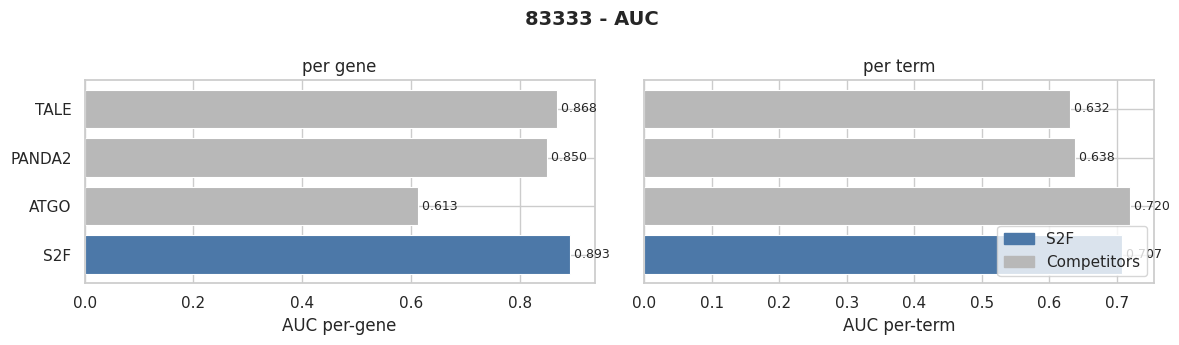

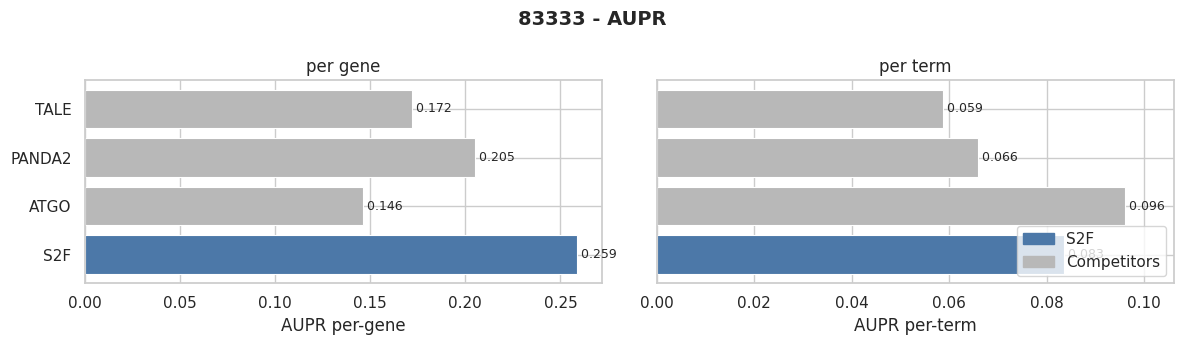

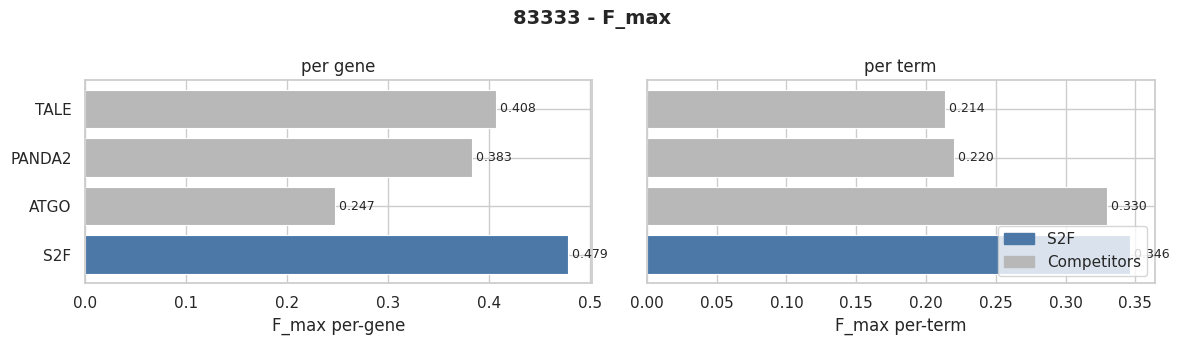

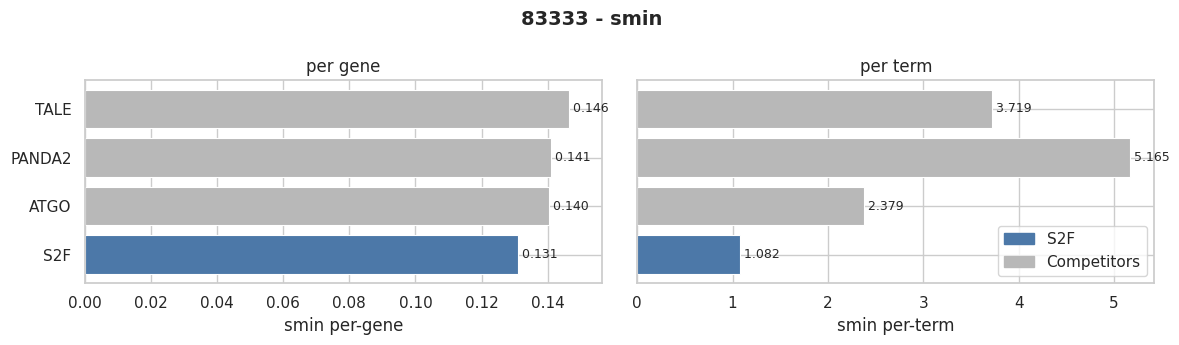

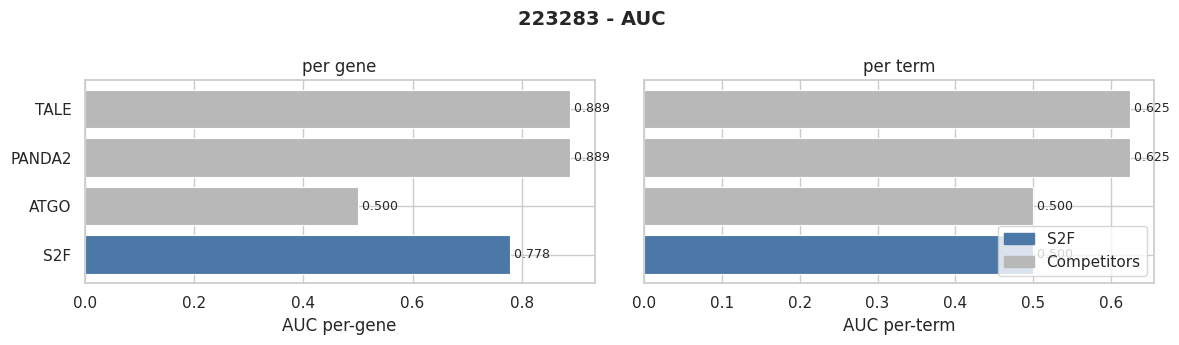

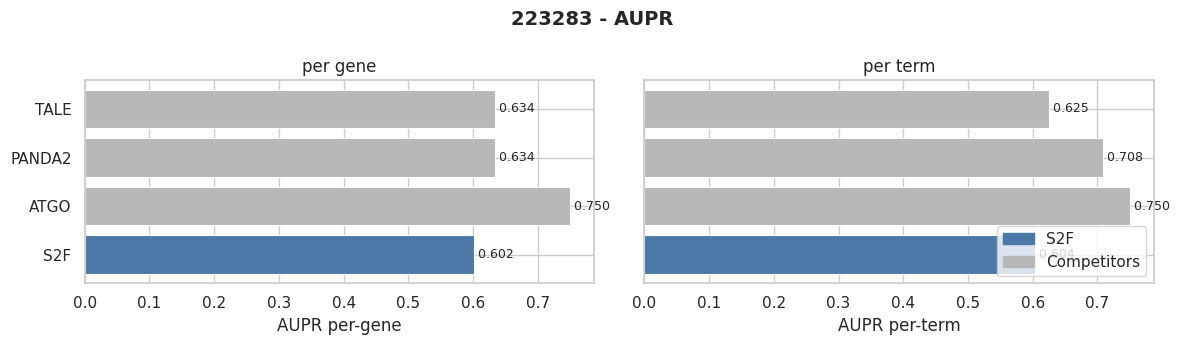

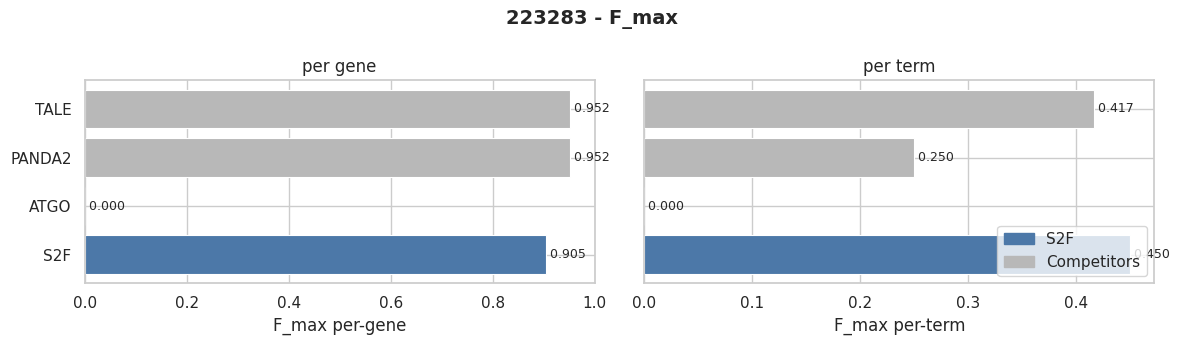

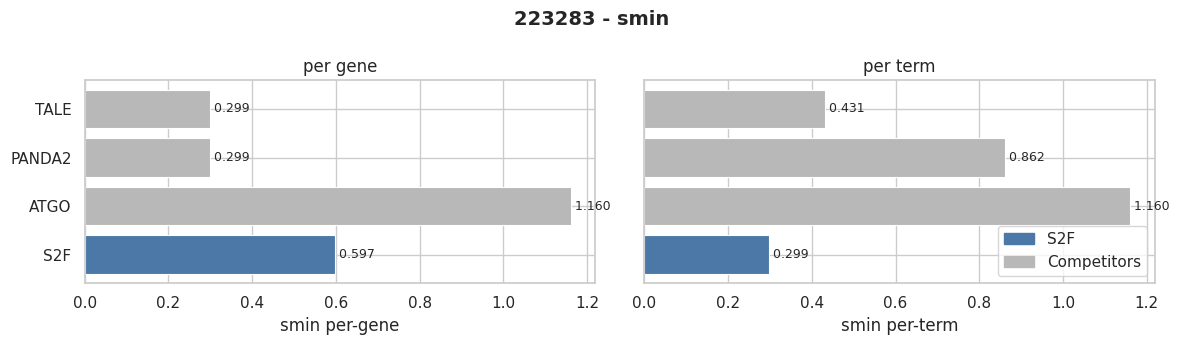

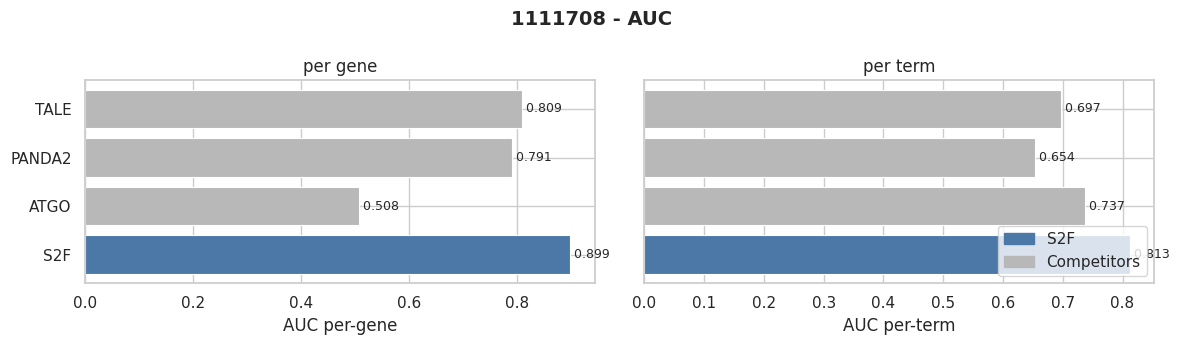

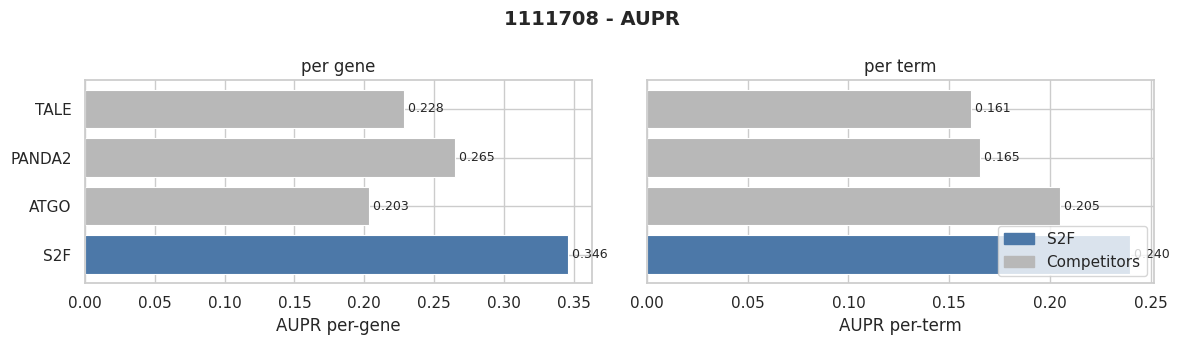

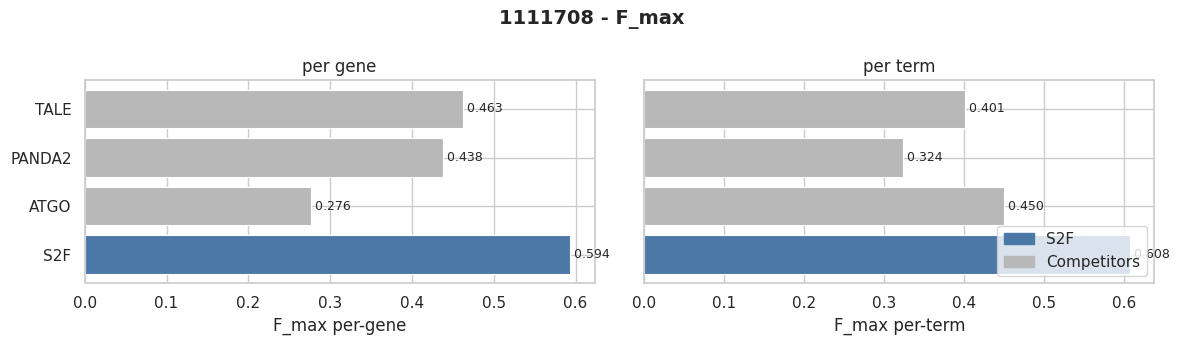

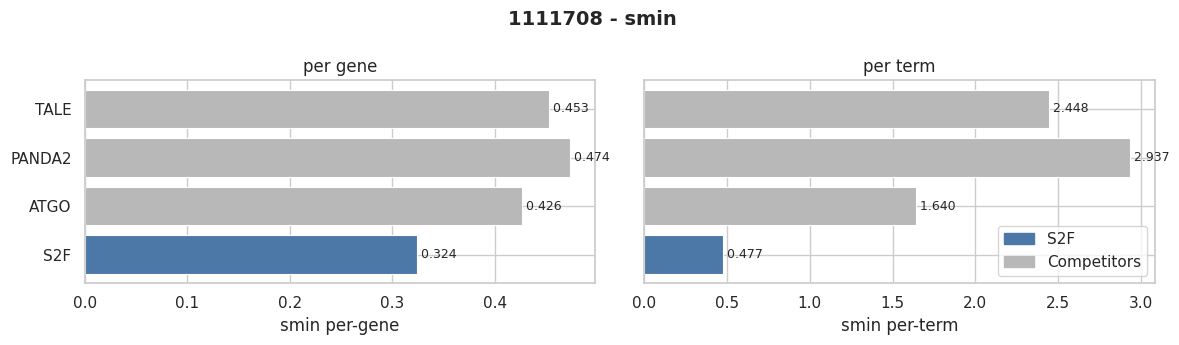

In [31]:
S2F_COLOR = '#4C78A8'
COMPETITOR_COLOR = '#B8B8B8'


def _unique_plot_labels(labels, models):
    counts = pd.Series(labels, dtype='object').value_counts()
    return [label if counts[label] == 1 else f'{label} [{model}]' for label, model in zip(labels, models)]


def plot_metric_for_organism(metrics_df, organism, metric_name, columns):
    organism_df = metrics_df[metrics_df['organism'].astype(str) == str(organism)].copy()
    if organism_df.empty:
        print(f'No metrics available for organism {organism}.')
        return None

    organism_df = organism_df.sort_values(['is_s2f', 'model'], ascending=[False, True])
    labels = _unique_plot_labels(organism_df['plot_label'].astype(str).tolist(), organism_df['model'].astype(str).tolist())
    colors = [S2F_COLOR if is_s2f else COMPETITOR_COLOR for is_s2f in organism_df['is_s2f']]

    fig, axes = plt.subplots(1, 2, figsize=(12, max(3.5, 0.45 * len(organism_df) + 1.5)), sharey=True)
    fig.suptitle(f'{organism} - {metric_name}', fontsize=14, fontweight='bold')

    for ax, column, subtitle in zip(axes, columns, ('per gene', 'per term')):
        values = pd.to_numeric(organism_df[column], errors='coerce')
        ax.barh(labels, values, color=colors, edgecolor='white', linewidth=0.8)
        ax.set_title(subtitle)
        ax.set_xlabel(column)
        ax.invert_yaxis()

        finite_values = values[np.isfinite(values)]
        if not finite_values.empty:
            padding = max(float(finite_values.max()) * 0.05, 0.01)
            ax.set_xlim(left=0, right=float(finite_values.max()) + padding)

        for y_pos, value in enumerate(values):
            if pd.notna(value):
                ax.text(value, y_pos, f' {value:.3f}', va='center', fontsize=9)

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=S2F_COLOR, label='S2F'),
        plt.Rectangle((0, 0), 1, 1, color=COMPETITOR_COLOR, label='Competitors'),
    ]
    axes[-1].legend(handles=legend_handles, loc='lower right')
    fig.tight_layout()
    return fig


for organism in ORGANISMS_TO_EVALUATE:
    for metric_name, columns in METRIC_SPECS.items():
        plot_metric_for_organism(FINAL_METRICS_DF, organism, metric_name, columns)

## Deep analysis

Use these cells to inspect the exact `(protein_id, GO term)` pairs behind a model/organism evaluation. The pair table includes every scored prediction plus every gold annotation pair, so false positives and false negatives are visible without materializing the enormous set of unpredicted true negatives.

In [32]:
DEEP_ANALYSIS_ORGANISM = ORGANISMS_TO_EVALUATE[0]
DEEP_ANALYSIS_THRESHOLD = 0.5  # use 'best_f1' to infer a threshold from the pair table
DEEP_ANALYSIS_TOP_N = 50
DEEP_ANALYSIS_OUTCOMES = None  # example: ['TP', 'FP', 'FN']
DEEP_ANALYSIS_MIN_SCORE = None


def _term_label(term_id, ontology):
    try:
        term = ontology.find_term(term_id)
        return term.name
    except Exception:
        return None


def _resolve_threshold_values(scores, labels, threshold):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=bool)
    if isinstance(threshold, str) and threshold.lower() == 'best_f1':
        thresholds = np.unique(scores)
        if thresholds.size == 0:
            return 0.5, np.nan

        best_threshold = float(thresholds[0])
        best_f1 = -1.0
        for candidate in thresholds:
            predicted = scores >= candidate
            tp = np.sum(predicted & labels)
            fp = np.sum(predicted & ~labels)
            fn = np.sum(~predicted & labels)
            precision = tp / (tp + fp) if (tp + fp) else 0.0
            recall = tp / (tp + fn) if (tp + fn) else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
            if f1 > best_f1:
                best_f1 = float(f1)
                best_threshold = float(candidate)
        return best_threshold, best_f1

    return float(threshold), np.nan


def _resolve_pair_threshold(pair_df, threshold):
    return _resolve_threshold_values(
        pair_df['score'].to_numpy(dtype=float),
        pair_df['gold_label'].to_numpy(dtype=bool),
        threshold,
    )


def build_pair_level_analysis(model, organism=DEEP_ANALYSIS_ORGANISM, threshold=DEEP_ANALYSIS_THRESHOLD):
    organism = str(organism)
    model = str(model)
    if organism not in ORGANISM_PROTEIN_SETS:
        raise ValueError(f'Organism {organism} is not present in ORGANISM_PROTEIN_SETS.')
    if model not in MODEL_LOADERS:
        raise ValueError(f'Model {model} is not present in MODEL_LOADERS.')

    evaluation_proteins = EVALUATION_PROTEIN_SETS[organism]
    predictions = MODEL_LOADERS[model](organism, evaluation_proteins)
    predictions = normalise_prediction_frame(predictions, model=model, organism=organism)

    ground_truth = prepare_ground_truth(organism)
    annotations = ground_truth['annotations'][['Protein', 'GO ID']].drop_duplicates()
    annotations = annotations[annotations['Protein'].astype(str).isin(evaluation_proteins)].copy()
    annotations = annotations.rename(columns={'Protein': 'protein_id', 'GO ID': 'term_id'})
    annotations['gold_label'] = 1

    valid_terms = set(annotations['term_id'])
    predictions = predictions[predictions['term_id'].isin(valid_terms)].copy()
    pred_pairs = predictions[['protein_id', 'term_id', 'score']].drop_duplicates()

    pair_df = pred_pairs.merge(annotations, how='outer', on=['protein_id', 'term_id'])
    if pair_df.empty:
        raise ValueError(f'No prediction/gold pairs available for {model} on {organism}.')

    pair_df['score'] = pd.to_numeric(pair_df['score'], errors='coerce').fillna(0.0)
    pair_df['gold_label'] = pair_df['gold_label'].fillna(0).astype(int)
    pair_df['source'] = np.select(
        [pair_df['score'].gt(0) & pair_df['gold_label'].eq(1), pair_df['score'].gt(0), pair_df['gold_label'].eq(1)],
        ['predicted_and_gold', 'predicted_only', 'gold_only'],
        default='materialized_zero',
    )

    threshold_used, best_f1 = _resolve_pair_threshold(pair_df, threshold)
    pair_df['threshold'] = threshold_used
    pair_df['predicted_positive'] = pair_df['score'] >= threshold_used
    pair_df['outcome'] = np.select(
        [
            pair_df['predicted_positive'] & pair_df['gold_label'].eq(1),
            pair_df['predicted_positive'] & pair_df['gold_label'].eq(0),
            ~pair_df['predicted_positive'] & pair_df['gold_label'].eq(1),
            ~pair_df['predicted_positive'] & pair_df['gold_label'].eq(0),
        ],
        ['TP', 'FP', 'FN', 'TN'],
        default='unknown',
    )

    ontology = ground_truth['ontology']
    pair_df['term_name'] = pair_df['term_id'].map(lambda term_id: _term_label(term_id, ontology))
    pair_df['organism'] = organism
    pair_df['model'] = model
    pair_df = pair_df.sort_values(['score', 'gold_label', 'protein_id', 'term_id'], ascending=[False, False, True, True])
    pair_df['score_rank_desc'] = np.arange(1, len(pair_df) + 1)

    ordered_columns = [
        'organism', 'model', 'protein_id', 'term_id', 'term_name', 'score',
        'gold_label', 'threshold', 'predicted_positive', 'outcome', 'source', 'score_rank_desc',
    ]
    pair_df = pair_df[ordered_columns]

    summary = (
        pair_df['outcome']
        .value_counts()
        .reindex(['TP', 'FP', 'FN', 'TN'], fill_value=0)
        .rename_axis('outcome')
        .reset_index(name='pairs')
    )
    summary['organism'] = organism
    summary['model'] = model
    summary['threshold'] = threshold_used
    summary['best_f1'] = best_f1
    summary = summary[['organism', 'model', 'threshold', 'best_f1', 'outcome', 'pairs']]

    return pair_df, summary


def filter_pair_analysis(pair_df, outcomes=DEEP_ANALYSIS_OUTCOMES, min_score=DEEP_ANALYSIS_MIN_SCORE):
    filtered = pair_df.copy()
    if outcomes:
        filtered = filtered[filtered['outcome'].isin(outcomes)]
    if min_score is not None:
        filtered = filtered[filtered['score'] >= float(min_score)]
    return filtered


def show_pair_level_analysis(model, organism=DEEP_ANALYSIS_ORGANISM, threshold=DEEP_ANALYSIS_THRESHOLD, top_n=DEEP_ANALYSIS_TOP_N):
    pair_df, summary = build_pair_level_analysis(model=model, organism=organism, threshold=threshold)
    filtered = filter_pair_analysis(pair_df)
    print(f'{model} {organism}: {len(pair_df):,} materialized prediction/gold pairs at threshold {summary["threshold"].iloc[0]:.4f}.')
    display(summary)
    display(filtered.head(top_n))
    return pair_df, summary


### S2F pair-level inspection

In [33]:
S2F_PAIR_ANALYSIS, S2F_PAIR_SUMMARY = show_pair_level_analysis('S2F')

S2F 83333: 702,080 unique predictions from 702,080 kept rows out of 302,547,575 raw rows.
S2F 83333: 90,410 materialized prediction/gold pairs at threshold 0.5000.


,organism,model,threshold,best_f1,outcome,pairs
0,83333,S2F,0.5,NaN,TP,0
1,83333,S2F,0.5,NaN,FP,14
2,83333,S2F,0.5,NaN,FN,1922
3,83333,S2F,0.5,NaN,TN,88474


,organism,model,protein_id,term_id,term_name,score,gold_label,threshold,predicted_positive,outcome,source,score_rank_desc
44197,83333,S2F,P37640,GO:0008150,biological_process,0.521611,0,0.5,True,FP,predicted_only,1
44531,83333,S2F,P37640,GO:0065007,biological regulation,0.521460,0,0.5,True,FP,predicted_only,2
44489,83333,S2F,P37640,GO:0050789,regulation of biological process,0.521453,0,0.5,True,FP,predicted_only,3
44490,83333,S2F,P37640,GO:0050794,regulation of cellular process,0.521446,0,0.5,True,FP,predicted_only,4
44337,83333,S2F,P37640,GO:0019222,regulation of metabolic process,0.521174,0,0.5,True,FP,predicted_only,5
...,...,...,...,...,...,...,...,...,...,...,...,...
34167,83333,S2F,P23484,GO:0019222,regulation of metabolic process,0.429810,0,0.5,False,TN,predicted_only,46
50317,83333,S2F,P39409,GO:0003824,catalytic activity,0.429806,0,0.5,False,TN,predicted_only,47
5265,83333,S2F,P06974,GO:0009987,cellular process,0.429803,0,0.5,False,TN,predicted_only,48
34355,83333,S2F,P23484,GO:0060255,regulation of macromolecule metabolic process,0.429801,0,0.5,False,TN,predicted_only,49


### TALE pair-level inspection

In [34]:
TALE_PAIR_ANALYSIS, TALE_PAIR_SUMMARY = show_pair_level_analysis('TALE')

TALE 83333: 48,000 unique predictions from raw counts {'bp': 16000, 'mf': 16000, 'cc': 16000}; malformed lines {}.
TALE 83333: 20,262 materialized prediction/gold pairs at threshold 0.5000.


,organism,model,threshold,best_f1,outcome,pairs
0,83333,TALE,0.5,NaN,TP,599
1,83333,TALE,0.5,NaN,FP,1588
2,83333,TALE,0.5,NaN,FN,1323
3,83333,TALE,0.5,NaN,TN,16752


,organism,model,protein_id,term_id,term_name,score,gold_label,threshold,predicted_positive,outcome,source,score_rank_desc
28,83333,TALE,E2JKY7,GO:0008150,biological_process,1.0,1,0.5,True,TP,predicted_and_gold,1
126,83333,TALE,G3MTW7,GO:0003674,molecular_function,1.0,1,0.5,True,TP,predicted_and_gold,2
239,83333,TALE,O32583,GO:0003674,molecular_function,1.0,1,0.5,True,TP,predicted_and_gold,3
254,83333,TALE,O32583,GO:0005575,cellular_component,1.0,1,0.5,True,TP,predicted_and_gold,4
271,83333,TALE,O32583,GO:0008150,biological_process,1.0,1,0.5,True,TP,predicted_and_gold,5
...,...,...,...,...,...,...,...,...,...,...,...,...
3591,83333,TALE,P0AB20,GO:0008150,biological_process,1.0,1,0.5,True,TP,predicted_and_gold,46
3698,83333,TALE,P0ABF4,GO:0003674,molecular_function,1.0,1,0.5,True,TP,predicted_and_gold,47
3727,83333,TALE,P0ABF4,GO:0008150,biological_process,1.0,1,0.5,True,TP,predicted_and_gold,48
3867,83333,TALE,P0ABW9,GO:0005575,cellular_component,1.0,1,0.5,True,TP,predicted_and_gold,49


### ATGO pair-level inspection

In [35]:
ATGO_PAIR_ANALYSIS, ATGO_PAIR_SUMMARY = show_pair_level_analysis('ATGO')

ATGO 83333: 26,942 unique predictions from raw counts {'BP': 20201, 'MF': 3494, 'CC': 3247}; missing proteins {}; malformed lines {}.
ATGO 83333: 13,327 materialized prediction/gold pairs at threshold 0.5000.


,organism,model,threshold,best_f1,outcome,pairs
0,83333,ATGO,0.5,NaN,TP,443
1,83333,ATGO,0.5,NaN,FP,1272
2,83333,ATGO,0.5,NaN,FN,1479
3,83333,ATGO,0.5,NaN,TN,10133


,organism,model,protein_id,term_id,term_name,score,gold_label,threshold,predicted_positive,outcome,source,score_rank_desc
10537,83333,ATGO,P76092,GO:0003824,catalytic activity,0.999999,0,0.5,True,FP,predicted_only,1
6408,83333,ATGO,P37440,GO:0003824,catalytic activity,0.999999,1,0.5,True,TP,predicted_and_gold,2
6449,83333,ATGO,P37440,GO:0016491,oxidoreductase activity,0.999999,1,0.5,True,TP,predicted_and_gold,3
5113,83333,ATGO,P24175,GO:0003824,catalytic activity,0.999999,0,0.5,True,FP,predicted_only,4
7891,83333,ATGO,P52037,GO:0003824,catalytic activity,0.999995,0,0.5,True,FP,predicted_only,5
...,...,...,...,...,...,...,...,...,...,...,...,...
7240,83333,ATGO,P39368,GO:0003824,catalytic activity,0.999034,0,0.5,True,FP,predicted_only,46
945,83333,ATGO,P08190,GO:0110165,cellular anatomical structure,0.998951,1,0.5,True,TP,predicted_and_gold,47
3470,83333,ATGO,P0C8J8,GO:0003824,catalytic activity,0.998836,0,0.5,True,FP,predicted_only,48
3061,83333,ATGO,P0ADQ2,GO:0003824,catalytic activity,0.998834,0,0.5,True,FP,predicted_only,49


### PANDA2 pair-level inspection

In [36]:
PANDA2_PAIR_ANALYSIS, PANDA2_PAIR_SUMMARY = show_pair_level_analysis('PANDA2')

PANDA2 83333: 20,831 unique predictions from 20,831 parsed rows; skipped 1,583,641 rows outside GOA taxon proteins; malformed lines 0.
PANDA2 83333: 12,606 materialized prediction/gold pairs at threshold 0.5000.


,organism,model,threshold,best_f1,outcome,pairs
0,83333,PANDA2,0.5,NaN,TP,629
1,83333,PANDA2,0.5,NaN,FP,1808
2,83333,PANDA2,0.5,NaN,FN,1293
3,83333,PANDA2,0.5,NaN,TN,8876


,organism,model,protein_id,term_id,term_name,score,gold_label,threshold,predicted_positive,outcome,source,score_rank_desc
1911,83333,PANDA2,P0AAI1,GO:0008150,biological_process,0.96,1,0.5,True,TP,predicted_and_gold,1
3396,83333,PANDA2,P0DP90,GO:0008150,biological_process,0.96,1,0.5,True,TP,predicted_and_gold,2
4769,83333,PANDA2,P24175,GO:0008150,biological_process,0.96,1,0.5,True,TP,predicted_and_gold,3
9701,83333,PANDA2,P76027,GO:0008150,biological_process,0.96,1,0.5,True,TP,predicted_and_gold,4
542,83333,PANDA2,P06864,GO:0008150,biological_process,0.96,0,0.5,True,FP,predicted_only,5
...,...,...,...,...,...,...,...,...,...,...,...,...
12439,83333,PANDA2,Q47147,GO:0008150,biological_process,0.93,0,0.5,True,FP,predicted_only,46
771,83333,PANDA2,P08189,GO:0008150,biological_process,0.92,1,0.5,True,TP,predicted_and_gold,47
3629,83333,PANDA2,P0DTT0,GO:0005622,intracellular anatomical structure,0.92,1,0.5,True,TP,predicted_and_gold,48
5857,83333,PANDA2,P37182,GO:0008150,biological_process,0.92,1,0.5,True,TP,predicted_and_gold,49


## Pair evidence summary for presentation

Run this after the per-model deep-analysis cells. It summarizes the exact protein-GO pair outcomes that explain the metric behavior for `DEEP_ANALYSIS_ORGANISM`.


In [40]:
PAIR_TABLE_VARIABLES = {
    'S2F': 'S2F_PAIR_ANALYSIS',
    'TALE': 'TALE_PAIR_ANALYSIS',
    'ATGO': 'ATGO_PAIR_ANALYSIS',
    'PANDA2': 'PANDA2_PAIR_ANALYSIS',
}


def build_pair_evidence_summary(top_n=10):
    pair_tables = {
        model: globals()[variable]
        for model, variable in PAIR_TABLE_VARIABLES.items()
        if variable in globals() and isinstance(globals()[variable], pd.DataFrame)
    }
    if not pair_tables:
        print('Run the per-model deep-analysis cells first to create S2F_PAIR_ANALYSIS, TALE_PAIR_ANALYSIS, ATGO_PAIR_ANALYSIS, and PANDA2_PAIR_ANALYSIS.')
        return pd.DataFrame(), pd.DataFrame()

    summary_rows = []
    example_rows = []
    for model, pair_df in pair_tables.items():
        counts = pair_df['outcome'].value_counts().to_dict()
        tp = counts.get('TP', 0)
        fp = counts.get('FP', 0)
        fn = counts.get('FN', 0)
        tn = counts.get('TN', 0)
        precision = tp / (tp + fp) if (tp + fp) else np.nan
        recall = tp / (tp + fn) if (tp + fn) else np.nan
        f1 = 2 * precision * recall / (precision + recall) if pd.notna(precision) and pd.notna(recall) and (precision + recall) else np.nan
        summary_rows.append({
            'organism': pair_df['organism'].iloc[0],
            'model': model,
            'threshold': pair_df['threshold'].iloc[0],
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'TN': tn,
            'precision_at_threshold': precision,
            'recall_at_threshold': recall,
            'f1_at_threshold': f1,
            'main_error_signal': 'many false positives' if fp > fn else 'many missed annotations',
        })

        for outcome in ['TP', 'FP', 'FN']:
            outcome_df = pair_df[pair_df['outcome'].eq(outcome)].copy()
            if outcome_df.empty:
                continue
            if outcome == 'FN':
                outcome_df = outcome_df.sort_values(['score', 'gold_label'], ascending=[False, False])
            else:
                outcome_df = outcome_df.sort_values(['score', 'gold_label'], ascending=[False, False])
            for _, row in outcome_df.head(top_n).iterrows():
                example_rows.append({
                    'organism': row['organism'],
                    'model': model,
                    'outcome': outcome,
                    'protein_id': row['protein_id'],
                    'term_id': row['term_id'],
                    'term_name': row['term_name'],
                    'score': row['score'],
                    'gold_label': row['gold_label'],
                    'why_it_matters': {
                        'TP': 'supports AUPR/Fmax because a true annotation received a high score',
                        'FP': 'hurts precision, AUPR, Fmax, and can increase smin',
                        'FN': 'hurts recall, Fmax, and can increase smin if the missed term is informative',
                    }[outcome],
                })

    return pd.DataFrame(summary_rows), pd.DataFrame(example_rows)


PAIR_EVIDENCE_SUMMARY_DF, PAIR_EVIDENCE_EXAMPLES_DF = build_pair_evidence_summary(top_n=10)

print('Pair outcome summary for the selected deep-analysis organism:')
display(PAIR_EVIDENCE_SUMMARY_DF)

print('Example protein-GO pairs driving the numbers:')
display(PAIR_EVIDENCE_EXAMPLES_DF)


Pair outcome summary for the selected deep-analysis organism:


,organism,model,threshold,TP,FP,FN,TN,precision_at_threshold,recall_at_threshold,f1_at_threshold,main_error_signal
0,83333,S2F,0.5,0,14,1922,88474,0.000000,0.000000,NaN,many missed annotations
1,83333,TALE,0.5,599,1588,1323,16752,0.273891,0.311655,0.291555,many false positives
2,83333,ATGO,0.5,443,1272,1479,10133,0.258309,0.230489,0.243607,many missed annotations
3,83333,PANDA2,0.5,629,1808,1293,8876,0.258104,0.327263,0.288598,many false positives


Example protein-GO pairs driving the numbers:


,organism,model,outcome,protein_id,term_id,term_name,score,gold_label,why_it_matters
0,83333,S2F,FP,P37640,GO:0008150,biological_process,0.521611,0,"hurts precision, AUPR, Fmax, and can increase ..."
1,83333,S2F,FP,P37640,GO:0065007,biological regulation,0.521460,0,"hurts precision, AUPR, Fmax, and can increase ..."
2,83333,S2F,FP,P37640,GO:0050789,regulation of biological process,0.521453,0,"hurts precision, AUPR, Fmax, and can increase ..."
3,83333,S2F,FP,P37640,GO:0050794,regulation of cellular process,0.521446,0,"hurts precision, AUPR, Fmax, and can increase ..."
4,83333,S2F,FP,P37640,GO:0019222,regulation of metabolic process,0.521174,0,"hurts precision, AUPR, Fmax, and can increase ..."
...,...,...,...,...,...,...,...,...,...
105,83333,PANDA2,FN,P0A7P5,GO:0003674,molecular_function,0.490000,1,"hurts recall, Fmax, and can increase smin if t..."
106,83333,PANDA2,FN,P0AB20,GO:0005488,binding,0.490000,1,"hurts recall, Fmax, and can increase smin if t..."
107,83333,PANDA2,FN,P0ACX9,GO:0005488,binding,0.490000,1,"hurts recall, Fmax, and can increase smin if t..."
108,83333,PANDA2,FN,P0ADQ2,GO:0044281,small molecule metabolic process,0.490000,1,"hurts recall, Fmax, and can increase smin if t..."


## Per-protein and per-term contribution analysis

These helpers recompute row-wise and column-wise metric components for one selected model/organism. Use them to identify the exact proteins and GO terms that drive poor or strong AUC, AUPR, Fmax, and semantic distance behavior.

In [41]:
CONTRIBUTION_MODEL = 'S2F'
CONTRIBUTION_ORGANISM = DEEP_ANALYSIS_ORGANISM
CONTRIBUTION_THRESHOLD = DEEP_ANALYSIS_THRESHOLD
CONTRIBUTION_TOP_N = 30


def build_evaluation_artifacts(model, organism):
    organism = str(organism)
    evaluation_proteins = EVALUATION_PROTEIN_SETS[organism]
    predictions = MODEL_LOADERS[model](organism, evaluation_proteins)
    predictions = normalise_prediction_frame(predictions, model=model, organism=organism)
    ground_truth = prepare_ground_truth(organism)
    annotations = ground_truth['annotations']
    annotations = annotations[annotations['Protein'].astype(str).isin(evaluation_proteins)].copy()
    valid_terms = set(annotations['GO ID'])
    predictions = predictions[predictions['term_id'].isin(valid_terms)].copy()
    prediction_matrix, gold_matrix, protein_to_idx, term_to_idx = build_prediction_and_gold_matrices(predictions, annotations)
    ic_vector = compute_information_content(term_to_idx, ground_truth['ontology'], ground_truth['organism_name'])
    filtered_pred, filtered_gold, filtered_ic, row_mask, col_mask = filter_matrices(gold_matrix, prediction_matrix, ic_vector)

    proteins_by_idx = np.array([protein for protein, _ in sorted(protein_to_idx.items(), key=lambda item: item[1])], dtype=object)
    terms_by_idx = np.array([term for term, _ in sorted(term_to_idx.items(), key=lambda item: item[1])], dtype=object)
    return {
        'prediction': filtered_pred,
        'gold': filtered_gold,
        'ic': filtered_ic,
        'proteins': proteins_by_idx[row_mask],
        'terms': terms_by_idx[col_mask],
        'ontology': ground_truth['ontology'],
    }


def _safe_hx_metrics(pred_vector, gold_vector):
    metrics = HX_py.HX_iteration(pred_vector, gold_vector)
    return {key: metrics.get(key, np.nan) for key in ['AUC', 'AUPR', 'F_max', 'NDCG', 'Jaccard']}


def build_contribution_tables(model=CONTRIBUTION_MODEL, organism=CONTRIBUTION_ORGANISM, threshold=CONTRIBUTION_THRESHOLD):
    artifacts = build_evaluation_artifacts(model, organism)
    pred = artifacts['prediction']
    gold = artifacts['gold']
    ic = artifacts['ic']
    measure = HX_py(pred, ic, organism_id=f'{model}_{organism}', verbose=False)
    threshold_used, _ = _resolve_threshold_values(pred.ravel(), gold.ravel(), threshold)

    protein_rows = []
    for idx, protein_id in enumerate(artifacts['proteins']):
        row_metrics = _safe_hx_metrics(pred[idx, :], gold[idx, :])
        s_metrics = measure.compute_s_measure(pred[idx, :], gold[idx, :], np.unique(pred[idx, :]))
        protein_rows.append({
            'organism': str(organism),
            'model': model,
            'protein_id': protein_id,
            'gold_terms': int(gold[idx, :].sum()),
            'predicted_positive_terms': int((pred[idx, :] >= threshold_used).sum()),
            **row_metrics,
            'smin': s_metrics['smin'],
        })

    term_rows = []
    ontology = artifacts['ontology']
    for idx, term_id in enumerate(artifacts['terms']):
        col_metrics = _safe_hx_metrics(pred[:, idx], gold[:, idx])
        s_metrics = measure.compute_s_measure(pred[:, idx], gold[:, idx], np.unique(pred[:, idx]), ic=ic[idx])
        term_rows.append({
            'organism': str(organism),
            'model': model,
            'term_id': term_id,
            'term_name': _term_label(term_id, ontology),
            'gold_proteins': int(gold[:, idx].sum()),
            'predicted_positive_proteins': int((pred[:, idx] >= threshold_used).sum()),
            'information_content': float(ic[idx]),
            **col_metrics,
            'smin': s_metrics['smin'],
        })

    protein_df = pd.DataFrame(protein_rows).sort_values(['AUPR', 'F_max', 'AUC'], ascending=[True, True, True])
    term_df = pd.DataFrame(term_rows).sort_values(['AUPR', 'F_max', 'AUC'], ascending=[True, True, True])
    return protein_df, term_df


PROTEIN_CONTRIBUTIONS_DF, TERM_CONTRIBUTIONS_DF = build_contribution_tables()
print(f'Worst {CONTRIBUTION_TOP_N} proteins by AUPR/Fmax/AUC:')
display(PROTEIN_CONTRIBUTIONS_DF.head(CONTRIBUTION_TOP_N))
print(f'Worst {CONTRIBUTION_TOP_N} GO terms by AUPR/Fmax/AUC:')
display(TERM_CONTRIBUTIONS_DF.head(CONTRIBUTION_TOP_N))

S2F 83333: 702,080 unique predictions from 702,080 kept rows out of 302,547,575 raw rows.
Worst 30 proteins by AUPR/Fmax/AUC:


,organism,model,protein_id,gold_terms,predicted_positive_terms,AUC,AUPR,F_max,NDCG,Jaccard,smin
109,83333,S2F,P64638,6,0,0.683099,0.023635,0.285714,0.524202,0.166667,0.076540
44,83333,S2F,P0C8K0,5,0,0.770826,0.025223,0.142857,0.287431,0.076923,0.090265
43,83333,S2F,P0C8J8,5,0,0.781722,0.026057,0.142857,0.289883,0.076923,0.090265
156,83333,S2F,Q46906,3,0,0.923526,0.030780,0.096774,0.263641,0.050847,0.030372
85,83333,S2F,P39332,3,0,0.952131,0.030836,0.500000,0.640686,0.333333,0.020038
...,...,...,...,...,...,...,...,...,...,...,...
49,83333,S2F,P0DSF8,11,0,0.695947,0.083449,0.266667,0.466850,0.153846,0.181218
78,83333,S2F,P37640,3,14,0.973730,0.085599,0.260870,0.338970,0.150000,0.030372
96,83333,S2F,P52037,3,0,0.982487,0.085741,0.500000,0.704768,0.333333,0.020038
132,83333,S2F,P76509,2,0,0.770979,0.086200,0.400000,0.382846,0.250000,0.028941


Worst 30 GO terms by AUPR/Fmax/AUC:


,organism,model,term_id,term_name,gold_proteins,predicted_positive_proteins,information_content,AUC,AUPR,F_max,NDCG,Jaccard,smin
23,83333,S2F,GO:0003700,DNA-binding transcription factor activity,1,0,9.906753,1.0,0.0,1.0,1.0,1.0,0.0
28,83333,S2F,GO:0003905,alkylbase DNA N-glycosylase activity,1,0,15.521462,1.0,0.0,1.0,1.0,1.0,0.0
29,83333,S2F,GO:0003924,GTPase activity,1,0,11.821023,1.0,0.0,1.0,1.0,1.0,0.0
30,83333,S2F,GO:0004141,dethiobiotin synthase activity,1,0,15.521462,1.0,0.0,1.0,1.0,1.0,0.0
47,83333,S2F,GO:0005216,monoatomic ion channel activity,1,0,12.129145,1.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,83333,S2F,GO:0009409,response to cold,1,0,12.351538,1.0,0.0,1.0,1.0,1.0,0.0
169,83333,S2F,GO:0009431,"bacterial-type flagellum basal body, MS ring",1,0,16.521461,1.0,0.0,1.0,1.0,1.0,0.0
194,83333,S2F,GO:0015035,protein-disulfide reductase activity,1,0,13.199534,1.0,0.0,1.0,1.0,1.0,0.0
195,83333,S2F,GO:0015036,disulfide oxidoreductase activity,1,0,12.521462,1.0,0.0,1.0,1.0,1.0,0.0


## S2F versus competitor pair comparison

This table joins S2F and one competitor on `(protein_id, term_id)` and classifies where S2F rescues competitor false negatives, where competitors rescue S2F false negatives, and where either model adds false positives.

In [38]:
COMPARISON_ORGANISM = DEEP_ANALYSIS_ORGANISM
COMPARISON_COMPETITOR = 'PANDA2'
COMPARISON_TOP_N = 50


def compare_s2f_to_competitor(competitor_model=COMPARISON_COMPETITOR, organism=COMPARISON_ORGANISM, threshold=DEEP_ANALYSIS_THRESHOLD):
    s2f_pairs, _ = build_pair_level_analysis('S2F', organism=organism, threshold=threshold)
    competitor_pairs, _ = build_pair_level_analysis(competitor_model, organism=organism, threshold=threshold)

    s2f_cols = s2f_pairs[['protein_id', 'term_id', 'term_name', 'score', 'gold_label', 'outcome']].rename(
        columns={'score': 's2f_score', 'outcome': 's2f_outcome'}
    )
    competitor_cols = competitor_pairs[['protein_id', 'term_id', 'score', 'outcome']].rename(
        columns={'score': 'competitor_score', 'outcome': 'competitor_outcome'}
    )
    comparison = s2f_cols.merge(competitor_cols, how='outer', on=['protein_id', 'term_id'])
    comparison['term_name'] = comparison['term_name'].fillna('')
    comparison['gold_label'] = comparison['gold_label'].fillna(0).astype(int)
    comparison['s2f_score'] = comparison['s2f_score'].fillna(0.0)
    comparison['competitor_score'] = comparison['competitor_score'].fillna(0.0)
    comparison['s2f_outcome'] = comparison['s2f_outcome'].fillna('TN')
    comparison['competitor_outcome'] = comparison['competitor_outcome'].fillna('TN')

    comparison['comparison'] = np.select(
        [
            comparison['s2f_outcome'].eq('TP') & comparison['competitor_outcome'].eq('FN'),
            comparison['s2f_outcome'].eq('FN') & comparison['competitor_outcome'].eq('TP'),
            comparison['s2f_outcome'].eq('TP') & comparison['competitor_outcome'].eq('TP'),
            comparison['s2f_outcome'].eq('FP') & comparison['competitor_outcome'].ne('FP'),
            comparison['competitor_outcome'].eq('FP') & comparison['s2f_outcome'].ne('FP'),
            comparison['s2f_outcome'].eq('FN') & comparison['competitor_outcome'].eq('FN'),
        ],
        [
            's2f_rescues_competitor_fn',
            'competitor_rescues_s2f_fn',
            'both_true_positive',
            's2f_only_false_positive',
            'competitor_only_false_positive',
            'both_false_negative',
        ],
        default='other',
    )
    comparison['s2f_minus_competitor_score'] = comparison['s2f_score'] - comparison['competitor_score']
    return comparison.sort_values(['comparison', 'gold_label', 's2f_minus_competitor_score'], ascending=[True, False, False])


S2F_COMPETITOR_PAIR_COMPARISON = compare_s2f_to_competitor()
S2F_COMPETITOR_PAIR_SUMMARY = (
    S2F_COMPETITOR_PAIR_COMPARISON['comparison']
    .value_counts()
    .rename_axis('comparison')
    .reset_index(name='pairs')
)

display(S2F_COMPETITOR_PAIR_SUMMARY)
display(S2F_COMPETITOR_PAIR_COMPARISON.head(COMPARISON_TOP_N))

S2F 83333: 702,080 unique predictions from 702,080 kept rows out of 302,547,575 raw rows.
PANDA2 83333: 20,831 unique predictions from 20,831 parsed rows; skipped 1,583,641 rows outside GOA taxon proteins; malformed lines 0.


,comparison,pairs
0,other,86694
1,competitor_only_false_positive,1794
2,both_false_negative,1293
3,competitor_rescues_s2f_fn,629


,protein_id,term_id,term_name,s2f_score,gold_label,s2f_outcome,competitor_score,competitor_outcome,comparison,s2f_minus_competitor_score
88087,Q2EEQ2,GO:0110165,cellular anatomical structure,0.429691,1,FN,0.0,FN,both_false_negative,0.429691
34414,P23484,GO:0140110,transcription regulator activity,0.429681,1,FN,0.0,FN,both_false_negative,0.429681
33928,P23484,GO:0003700,DNA-binding transcription factor activity,0.429674,1,FN,0.0,FN,both_false_negative,0.429674
9545,P0A7P5,GO:0110165,cellular anatomical structure,0.429585,1,FN,0.0,FN,both_false_negative,0.429585
8578,P0A6E9,GO:0006768,biotin metabolic process,0.383469,1,FN,0.0,FN,both_false_negative,0.383469
...,...,...,...,...,...,...,...,...,...,...
36855,P30015,GO:0008186,"ATP-dependent activity, acting on RNA",0.199567,1,FN,0.0,FN,both_false_negative,0.199567
69307,P76004,GO:0043648,dicarboxylic acid metabolic process,0.199541,1,FN,0.0,FN,both_false_negative,0.199541
69183,P76004,GO:0016860,intramolecular oxidoreductase activity,0.199532,1,FN,0.0,FN,both_false_negative,0.199532
69009,P76004,GO:0006107,oxaloacetate metabolic process,0.199531,1,FN,0.0,FN,both_false_negative,0.199531


## Why can a simple KNN obtain a strong Fmax?

Generated from the post-blacklist diagnostics at `2026-07-20T21:22:08.955888+00:00`. 
The code cells below load the same JSON used by the explorer. Archived pre-blacklist rows are not used.

### Current per-gene benchmark snapshot

| Organism | Method | Fmax | AUPR | AUROC | Smin |
|---|---|---:|---:|---:|---:|
| 83333 | S2F | 0.4787 | 0.2589 | 0.8931 | 0.1311 |
| 83333 | TALE | 0.4076 | 0.1717 | 0.8679 | 0.1463 |
| 83333 | ATGO | 0.2474 | 0.1462 | 0.6132 | 0.1403 |
| 83333 | PANDA2 | 0.3830 | 0.2052 | 0.8500 | 0.1411 |
| 83333 | KNN k=10 (weighted_support) | 0.4934 | 0.1195 | 0.8452 | 0.1573 |
| 1111708 | S2F | 0.5936 | 0.3458 | 0.8991 | 0.3244 |
| 1111708 | TALE | 0.4627 | 0.2284 | 0.8091 | 0.4527 |
| 1111708 | ATGO | 0.2760 | 0.2034 | 0.5075 | 0.4263 |
| 1111708 | PANDA2 | 0.4379 | 0.2646 | 0.7912 | 0.4740 |
| 1111708 | KNN k=10 (weighted_support) | 0.7099 | 0.1982 | 0.9134 | 0.2794 |

The reported per-gene Fmax is an **oracle average**: F1 is maximized independently for every protein, then averaged. The threshold diagnostics below contrast it with one shared threshold and repeated held-out threshold selection. AUPR instead scores the complete ranking, so it exposes poorly ordered false positives that a single best F1 point can hide.

> Smin warning: historical competitor Smin rows used full-organism information content, while Clean PLM used the shared evaluation set. Use `harmonized_value` for the fair same-IC sensitivity analysis.


In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

KNN10 = 'Clean PLM + KNN k=10 (weighted_support)'
ANALYSIS_PATH = next(
    candidate / 'notebooks/esm_go_explorer/data/knn_competitor_analysis.json'
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'notebooks/esm_go_explorer/data/knn_competitor_analysis.json').is_file()
)
KNN_ANALYSIS = json.loads(ANALYSIS_PATH.read_text())
METRIC_DF = pd.DataFrame(KNN_ANALYSIS['metric_rows'])
THRESHOLD_DF = pd.DataFrame(KNN_ANALYSIS['threshold_summary'])
SHARED_THRESHOLD_DF = pd.DataFrame(KNN_ANALYSIS['shared_threshold_summary'])
CV_THRESHOLD_DF = pd.DataFrame(KNN_ANALYSIS['cross_validation_summary'])
SCORE_DF = pd.DataFrame(KNN_ANALYSIS['score_summary'])
ONTOLOGY_DF = pd.DataFrame(KNN_ANALYSIS['ontology_rows'])
FREQUENCY_DF = pd.DataFrame(KNN_ANALYSIS['frequency_rows'])
NEIGHBOR_AUDIT_DF = pd.DataFrame(KNN_ANALYSIS['neighbor_audit'])
NEIGHBOR_PROFILE_DF = pd.DataFrame(KNN_ANALYSIS['neighbor_profiles'])
NEIGHBOR_CORRELATION_DF = pd.DataFrame(KNN_ANALYSIS['neighbor_correlations'])
EXAMPLE_DF = pd.DataFrame(KNN_ANALYSIS['examples'])
print('Loaded', ANALYSIS_PATH)
print('Generated', KNN_ANALYSIS['generated_at_utc'])


### Metric rankings and Smin comparability

Use the first table to reproduce the benchmark values. The second table puts every method on the same shared-evaluation-set information-content scale for Smin.


In [ ]:
PRIMARY = KNN_ANALYSIS['metadata']['primary_methods']
display(
    METRIC_DF.query("scope == 'per-gene' and method in @PRIMARY")
    .pivot(index=['organism', 'method'], columns='metric', values='value')
    .reset_index()
)
display(
    METRIC_DF.query("scope == 'per-gene' and metric == 'smin' and method in @PRIMARY")
    [['organism', 'method', 'value', 'harmonized_value', 'saved_information_content_scope']]
    .rename(columns={'value': 'saved_smin', 'harmonized_value': 'shared_set_ic_smin'})
)


### Is KNN's Fmax advantage threshold-specific?

`oracle_fmax` averages a separately optimized F1 for each protein. `shared_threshold_f1` uses one best threshold for the whole organism. `heldout_f1_mean` learns thresholds without the held-out proteins.


In [ ]:
threshold_comparison = (
    THRESHOLD_DF.query("scope == 'per-gene' and method in @PRIMARY")
    [['organism', 'method', 'oracle_fmax', 'optimal_threshold_median', 'precision_at_oracle_mean', 'recall_at_oracle_mean']]
    .merge(
        SHARED_THRESHOLD_DF.query("scope == 'per-gene' and method in @PRIMARY")
        [['organism', 'method', 'shared_threshold', 'shared_threshold_f1']],
        on=['organism', 'method'],
    )
    .merge(
        CV_THRESHOLD_DF.query("method in @PRIMARY")
        [['organism', 'method', 'threshold_mean', 'heldout_precision_mean', 'heldout_recall_mean', 'heldout_f1_mean']],
        on=['organism', 'method'],
    )
)
display(threshold_comparison)


### Score sparsity, repeated values, ontology, and GO-term frequency


In [ ]:
display(
    SCORE_DF.query('method in @PRIMARY')
    [['organism', 'method', 'nonzero_predictions', 'zero_fraction', 'unique_nonzero_scores',
      'most_repeated_score_count', 'score_median_nonzero', 'mean_predictions_per_protein']]
)
display(
    ONTOLOGY_DF.query("scope == 'per-gene' and ontology_roots == 'excluded' and metric in ['F_max', 'AUPR'] and method in @PRIMARY")
    .pivot(index=['organism', 'ontology', 'method'], columns='metric', values='value')
    .reset_index()
)
display(
    FREQUENCY_DF.query("scope == 'per-term' and metric in ['F_max', 'AUPR'] and method in @PRIMARY")
    .pivot(index=['organism', 'frequency_bin', 'method'], columns='metric', values='value')
    .reset_index()
)


### Post-blacklist neighbor evidence and paired protein examples


In [ ]:
display(NEIGHBOR_AUDIT_DF)
display(NEIGHBOR_CORRELATION_DF)
display(
    EXAMPLE_DF[['organism', 'direction', 'rank', 'protein_id', 'best_advanced_method',
                'knn_fmax', 'advanced_fmax', 'fmax_delta', 'knn_aupr', 'advanced_aupr']]
    .sort_values(['organism', 'direction', 'rank'])
)
print('The full machine-readable tables and bootstrap intervals are in notebooks/exports/knn_competitor_analysis/.')
